In [1]:
# Imports
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpltlib
from matplotlib.colors import BoundaryNorm, ListedColormap
import math

In [2]:
# Import data and selected proteins list
data_f = pd.read_csv('../data/PLF_Buckley_Female_YFZvsOJA.tsv', sep='\t')
data_m = pd.read_csv('../data/PLF_Buckley_Male_YFZvsOJA.tsv', sep='\t')

# Renames some columns for ease of use "to be modified based on data structure"
data_f = data_f.rename(columns={'p: Old vs Young' : 'p: Aged vs Young'})
data_m = data_m.rename(columns={'p: Old vs Young' : 'p: Aged vs Young'})

In [21]:
# Split data into your relevant conditionsfor ease of reference. eg. ffpi1 = fuzzy female specimen1 of this group

ffpi1 = data_f[(data_f["Original_FZ1_F (ms-status_RAT1)"] != 0)]
ffpi2 = data_f[(data_f["Original_FZ2_F (ms-status_RAT2)"] != 0)]
ffpi3 = data_f[(data_f["Original_FZ3_F (ms-status_RAT3)"] != 0)]

jfpi1 = data_f[(data_f["Original_JA2_F (ms-status_RAT8)"] != 0)]
jfpi2 = data_f[(data_f["Original_JA5_F (ms-status_RAT11)"] != 0)]
jfpi3 = data_f[(data_f["Original_JA6_F (ms-status_RAT12)"] != 0)]

fmpi1 = data_m[(data_m["Original_FZ4_M (ms-status_RAT4)"] != 0)]
fmpi2 = data_m[(data_m["Original_FZ5_M (ms-status_RAT5)"] != 0)]
fmpi3 = data_m[(data_m["Original_FZ6_M (ms-status_RAT6)"] != 0)]

jmpi1 = data_m[(data_m["Original_JA1_M (ms-status_RAT7)"] != 0)]
jmpi2 = data_m[(data_m["Original_JA3_M (ms-status_RAT9)"] != 0)]
jmpi3 = data_m[(data_m["Original_JA4_M (ms-status_RAT10)"] != 0)]

# Prints the number of unique Uniprot_IDs there are and then prints the average pre-calculated here. 
print('ffpi', ffpi1['Uniprot_ID'].unique().size, ffpi2['Uniprot_ID'].unique().size, ffpi3['Uniprot_ID'].unique().size, "70.3")
print('fmpi', fmpi1['Uniprot_ID'].unique().size, fmpi2['Uniprot_ID'].unique().size, fmpi3['Uniprot_ID'].unique().size, "78.3")
print('jfpi', jfpi1['Uniprot_ID'].unique().size, jfpi2['Uniprot_ID'].unique().size, jfpi3['Uniprot_ID'].unique().size, "59")
print('jmpi', jmpi1['Uniprot_ID'].unique().size, jmpi2['Uniprot_ID'].unique().size, jmpi3['Uniprot_ID'].unique().size, "61.6")

ffpi 64 84 63 70.3
fmpi 65 82 88 78.3
jfpi 66 55 56 59
jmpi 61 67 57 61.6


In [28]:
ffpi1

,Uniprot_ID,Domain_Name,Domain_Start,Domain_Finish,p: Aged vs Young,Domain Type,Domain_Length,FZ1_F (ms-status_RAT1),FZ2_F (ms-status_RAT2),FZ3_F (ms-status_RAT3),JA2_F (ms-status_RAT8),JA5_F (ms-status_RAT11),JA6_F (ms-status_RAT12),Diff Young vs old (average young - old / 50),Average Young,Average Old,Peptides contributing to Young,Peptides contributing to Old,Original_FZ1_F (ms-status_RAT1),Original_FZ2_F (ms-status_RAT2),Original_FZ3_F (ms-status_RAT3),Original_JA2_F (ms-status_RAT8),Original_JA5_F (ms-status_RAT11),Original_JA6_F (ms-status_RAT12),GeneAC,Uniprot_ACs
3,PRG2_RAT,50Step_Domain_p150.0_to_200.0,150,200,0.0010,50.0 AA STEP,50,1,1,1,1,0,0,0.020000,1,0,GINQGQVWIGGR,GINQGQVWIGGR,1,1,1,1,0,0,PRG2_RAT,Q63189;\r
9,TRFE_RAT,50Step_Domain_p0_to_50,0,50,0.8176,50.0 AA STEP,50,1,1,0,0,0,0,0.020000,1,0,NaN,NaN,1,1,0,0,0,0,TRFE_RAT,P12346;\rQ63602;\rQ64628;\rQ64630;\rQ7TNX0;\r
10,TRFE_RAT,50Step_Domain_p50.0_to_100.0,50,100,1.0000,50.0 AA STEP,50,1,0,0,0,0,0,0.000000,0,0,NaN,NaN,2,0,0,0,0,0,TRFE_RAT,P12346;\rQ63602;\rQ64628;\rQ64630;\rQ7TNX0;\r
11,TRFE_RAT,50Step_Domain_p100.0_to_150.0,100,150,0.0742,50.0 AA STEP,50,1,1,1,0,0,0,0.020000,1,0,GTDFQLNQLQGK,NaN,1,1,1,0,0,0,TRFE_RAT,P12346;\rQ63602;\rQ64628;\rQ64630;\rQ7TNX0;\r
13,TRFE_RAT,50Step_Domain_p200.0_to_250.0,200,250,0.0742,50.0 AA STEP,50,2,1,0,0,0,0,0.020000,1,0,NaN,NaN,3,2,0,0,0,0,TRFE_RAT,P12346;\rQ63602;\rQ64628;\rQ64630;\rQ7TNX0;\r
14,TRFE_RAT,50Step_Domain_p250.0_to_300.0,250,300,0.0000,50.0 AA STEP,50,2,2,3,0,0,0,0.040000,2,0,DFQLFGSPLGK KPVDQYEDCYLAR,NaN,3,4,2,0,0,0,TRFE_RAT,P12346;\rQ63602;\rQ64628;\rQ64630;\rQ7TNX0;\r
15,TRFE_RAT,50Step_Domain_p300.0_to_350.0,300,350,0.0000,50.0 AA STEP,50,2,3,4,0,0,0,0.060000,3,0,DFQLFGSPLGK DSAFGLLR LYLGHSYVTAIR,NaN,4,5,3,0,0,0,TRFE_RAT,P12346;\rQ63602;\rQ64628;\rQ64630;\rQ7TNX0;\r
16,TRFE_RAT,50Step_Domain_p350.0_to_400.0,350,400,0.0742,50.0 AA STEP,50,1,1,1,0,0,0,0.020000,1,0,WCALSHQER,NaN,1,1,1,0,0,0,TRFE_RAT,P12346;\rQ63602;\rQ64628;\rQ64630;\rQ7TNX0;\r
18,TRFE_RAT,50Step_Domain_p450.0_to_500.0,450,500,0.8176,50.0 AA STEP,50,1,1,0,0,0,0,0.020000,1,0,NaN,NaN,1,2,0,0,0,0,TRFE_RAT,P12346;\rQ63602;\rQ64628;\rQ64630;\rQ7TNX0;\r
19,TRFE_RAT,50Step_Domain_p500.0_to_550.0,500,550,0.8176,50.0 AA STEP,50,1,1,0,0,0,0,0.020000,1,0,NaN,NaN,2,1,0,0,0,0,TRFE_RAT,P12346;\rQ63602;\rQ64628;\rQ64630;\rQ7TNX0;\r


In [8]:
# Combines all the specimens of interest per condition you are comparing. eg. comparing fuzzy female rats to jumbo female rats. 
ffpi = data_f[(data_f["Original_FZ1_F (ms-status_RAT1)"] != 0) & (data_f["Original_FZ2_F (ms-status_RAT2)"] != 0) & (data_f["Original_FZ3_F (ms-status_RAT3)"] != 0)]
jfpi = data_f[(data_f["Original_JA2_F (ms-status_RAT8)"] != 0) & (data_f["Original_JA5_F (ms-status_RAT11)"] != 0) & (data_f["Original_JA6_F (ms-status_RAT12)"] != 0)]
fmpi = data_m[(data_m["Original_FZ4_M (ms-status_RAT4)"] != 0) & (data_m["Original_FZ5_M (ms-status_RAT5)"] != 0) & (data_m["Original_FZ6_M (ms-status_RAT6)"] != 0)]
jmpi = data_m[(data_m["Original_JA1_M (ms-status_RAT7)"] != 0) & (data_m["Original_JA3_M (ms-status_RAT9)"] != 0) & (data_m["Original_JA4_M (ms-status_RAT10)"] != 0)]

In [19]:
print('ffpi', ffpi['Uniprot_ID'].unique().size)
print('fmpi', fmpi['Uniprot_ID'].unique().size)
print('jfpi', jfpi['Uniprot_ID'].unique().size)
print('jmpi', jmpi['Uniprot_ID'].unique().size)

ffpi 49
fmpi 54
jfpi 49
jmpi 52


In [3]:
# Data structure: important columns for this datagroup: 
# 'uniprot_id' = protein_id
# 'Average_Young' = average peptide spectral count for sample group 1
# 'Average_Old' = average peptide spectral count for sample group 2
# 'Diff Young vs old (average young - old / 50)' = average normalised peptide spectral count
# 'p: Aged vs Young' = p_value

In [3]:
# Add standard deviation columns
## Notes:
# Strings "FZ1_F (ms-status_RAT1)" refer to a sample group within one of the datasets. As different datasets have different column
# names these can be changed depending on the column names applicable to a MPLF results dataset.
# 2 Sets of standard deviations are applied as as there are 2 sample groups; in this case "Old" and "Young" rat specimens. 
# If MPLF results.tsv export column indexes are always the same, the names of PSM sample columns could be replaced with column indexes. 
def addStandardDeviation(data, dataGroup):
    if dataGroup == 'female':
        compGroup1Names = dataGroup[0]
        compGroup2Names = dataGroup[1]
    else:
        compGroup1Names = dataGroup[0]
        compGroup2Names = dataGroup[1]
    g1 = 'Average_Young'
    g2 = 'Average_Old'
    data['SD_g1'] = 0
    data['SD_g2'] = 0
    for i, row in data.iterrows():
        data.at[i, 'SD_g1'] = row[compGroup1Names].std()
        data.at[i, 'SD_g2'] = row[compGroup2Names].std()
    return data

femaleGroupSampleNames = [['FZ1_F (ms-status_RAT1)', 'FZ2_F (ms-status_RAT2)', 'FZ3_F (ms-status_RAT3)'], ['JA2_F (ms-status_RAT8)', 'JA5_F (ms-status_RAT11)', 'JA6_F (ms-status_RAT12)']]
maleGroupSampleNames = [['FZ4_M (ms-status_RAT4)', 'FZ5_M (ms-status_RAT5)', 'FZ6_M (ms-status_RAT6)'], ['JA1_M (ms-status_RAT7)', 'JA3_M (ms-status_RAT9)', 'JA4_M (ms-status_RAT10)']]

data_f = addStandardDeviation(data_f, femaleGroupSampleNames)
data_m = addStandardDeviation(data_m, maleGroupSampleNames)

In [4]:
# Filter for significants - returns a list of unique proteins that are significant
## The filter ensures there is at least an average peptide spectral count (PSC) of > 1 in both conditions (old vs young)
## The difference in average peptide spectral count must also be greater than 1 between the conditions
## The p-value must be less than 0.05 level of significance
def filterData(data):
    data = data
    true_sigs = data[data['Average Young'] > 0]
    true_sigs = true_sigs[true_sigs['Average Old'] > 0]
    true_sigs = true_sigs[abs((true_sigs['Average Old'] - true_sigs['Average Young'])) > 1]
    if 'p: Old vs Young' in data.columns:
        only_sig = true_sigs[true_sigs['p: Old vs Young'] < 0.05]
    else:
        only_sig = true_sigs[true_sigs['p: Aged vs Young'] < 0.05]
    
    uniq = only_sig['Uniprot_ID'].unique()
    return uniq

data_f_sig_prots = filterData(data_f)
data_m_sig_prots = filterData(data_m)

In [5]:
## Finds proteins unique to each dataset and the ones found in both datasets
# Find common proteins - takes in two lists
def findCommon(data):
    # Convert lists to sets
    set1 = set(data[0])
    set2 = set(data[1])

    # Find intersection
    common_strings = set1.intersection(set2)

    common_proteins = set1 & set2
    unique_to_list1 = set1 - set2
    unique_to_list2 = set2 - set1

    # Convert the result back to a list if needed
    common_strings_list = list(common_strings)
    proteins_in_both = common_strings_list
    results = {
        'unique_to_g1': unique_to_list1,
        'unique_to_g2': unique_to_list2,
        'common_to_both': proteins_in_both
    }
    return results
common_proteins = findCommon([data_f_sig_prots, data_m_sig_prots])

In [6]:
# Defines colour palette to be used for the heatmaps 
colors = [(1, 1, 1), (1, 0, 0)]  # Transition from white (1, 1, 1) to red (1, 0, 0)
n_bins = 100  # Number of discrete steps in the colormap
cmap_name = 'white_to_red'  # Name of the colormap
cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

In [ ]:
# single dataset figure aspect ration: (32.5, 4)
# 2 datasets figure aspect ration: (27.5, 4)

In [7]:
# Visualise average peptide spectral counts
# Builds Bargraphs with heatmaps:
# Requires: d = data('dataframe') for a particular protein | p = protein_id (string) | g = sample_group (string)
# Optional: save = do you want the plot to be saved as an svg (Boolean) | titleExt - extension for main title string (String)
def BuildGraph(d, *args, **kwargs):
    # Save variables
    save = kwargs.get('save', None)
    titleExt = kwargs.get('titleExt', None)
    
    protein = kwargs.get('p', None) 
    g = kwargs.get('g', None) 
    s = kwargs.get('s', None)
    t = kwargs.get('t', None) 
    scale = kwargs.get('scale', None)
    if protein:
        proteins = d['Uniprot_ID'] == protein
    else:
        proteins = d['Uniprot_ID'].unique()
    
    for p in proteins:
    
        Protein = d[d['Uniprot_ID'] == p]
        SegmentValue = 50
        BarPos = SegmentValue / 2
        pml = Protein['Domain_Finish'].max()
        previous_value = 0

        GraphData = {
            'Segments': [],
            'Values': [],
            'HeatValues': [],
            'SD': [],
            'p_values': []
        }

        # Process data for plotting
        for index, row in Protein.iterrows():
            domainFinish = row['Domain_Finish'] - ((row['Domain_Finish'] - previous_value)/2)
            Aver = row[g]
            GraphData['Segments'].append(domainFinish)
            GraphData['Values'].append(Aver)
            previous_value = row['Domain_Finish']
            if g == 'Average Young':
                sdg = 'SD_g1'
                GraphData['SD'].append(row[sdg])
            else: 
                sdg = 'SD_g2'
                GraphData['SD'].append(row[sdg])
            # Standard Deviation
            #p-values
            GraphData['p_values'].append(row['p: Aged vs Young'])

        GraphData['HeatValues'] = np.array(GraphData['Values'])  # This should be outside the loop

        fig, axs = plt.subplots(2, 1, figsize=(15, 4), gridspec_kw={'height_ratios': [2, 0.5]}, layout='constrained')

        # Barchart
        ax1 = axs[0]
        ax2 = axs[1]

        ticks = []
        ticks = np.append(ticks, np.arange(0, pml, 50))
        ticks = np.append(ticks, pml)

        # highest value of for y axis combine value plus standard deviation
        max_y_with_SD = [a + b for a, b in zip(GraphData['Values'], GraphData['SD'])]
        
        ax1.set_xticks(ticks)
        ax1.set_xticklabels([])
        ax1.set_xlim(0, pml)
        if  max(GraphData['SD']) == 0:
            if (scale):
                ax1.set_ylim(0, scale + max(GraphData['SD']) + 0.25)
            else:
                ax1.set_ylim(0, max(GraphData['Values']) + 0.25)
        else: 
            if (scale):
                ax1.set_ylim(0, scale + max(GraphData['SD']) + 0.25)
            else:
                ax1.set_ylim(0, max(GraphData['Values']) + max(GraphData['SD']) + 0.25)
        
        # Plot bar
        segment_diff = np.diff(GraphData['Segments'])
        max_width = 0.75 * min(segment_diff)
        ax1.bar(GraphData['Segments'], GraphData['Values'], yerr = GraphData['SD'], width=max_width, error_kw={'elinewidth': 3}) 
        ax1.set_ylabel(t, fontsize=32)

        # Set y-axis tick positions and corresponding labels
        if scale:
            ax1.set_yticks([0, scale])  # Tick positions
            ax1.set_yticklabels(['', scale], fontsize=64)  # Tick labels as strings
        else:
            ax1.set_yticks([0, np.ceil(max(GraphData['Values']))])  # Tick positions
            ax1.set_yticklabels(['', int(np.ceil(max(GraphData['Values'])))], fontsize=64)  # Tick labels as strings
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        
        # Heatmap
        ax2.set_xticks(ticks)
        ax2.set_xlim(0, pml)
        ax2.set_xticklabels([], fontsize=8)
        ax2.set_ylim(0, 1)
        ax2.set_yticks([])
        ax2.grid(which="both", color="black", linewidth=1, alpha=1)
        
        ax1.tick_params(axis='x', labelrotation=45)  # Rotate labels by 45 degrees
        ax2.tick_params(axis='x', labelrotation=45)  # Rotate labels by 45 degrees
           
        # print(ticks, len(ticks), len(ticks[:-2]), len(GraphData['HeatValues']))
            
        ax2.pcolormesh(ticks, [0, 1], [GraphData['HeatValues']], cmap=cm, shading='flat')
        
        plt.tight_layout()
    if save:
        plt.savefig('scaled2/Bar_plot_{}_{}_{}.svg'.format(p, g, s), format='svg')
        plt.show()

In [8]:
# Builds difference in average spectral counts line/scatter plot:
# requires: d = data (dataframe) for a particular protein | p = uniprot_id (string)
# optional: addRegion = [(regionlabel, peptideposition, labelposition, labeloffset)], eg: ['NC1-start', 1208, 'center', 0.01)] labeloffset=0.01 (recommended)

def buildDiffGraph(d, *args, **kwargs):
    t = kwargs.get('t', None)
    g = kwargs.get('g', None)
    s = kwargs.get('s', None)
    addRegion = kwargs.get('addRegion', None)
    save = kwargs.get('save', None)
    proteins = d['Uniprot_ID'].unique()
    
    for p in proteins:
    
        Protein = d[d['Uniprot_ID'] == p]
        SegmentValue = 50
        BarPos = SegmentValue / 2
        pml = Protein['Domain_Finish'].max()
        previous_value = 0
        
        GraphData = {
            'Segments': [],
            'Values': [],
            'p_values': []
        }

        # Process data for plotting
        for index, row in Protein.iterrows():
            domainFinish = row['Domain_Finish'] - ((row['Domain_Finish'] - previous_value)/2)
            Aver = row['Diff Young vs old (average young - old / 50)']
            GraphData['Segments'].append(domainFinish)
            GraphData['Values'].append(Aver)
            GraphData['HeatValues'] = np.array(GraphData['Values'])
            GraphData['p_values'].append(row['p: Aged vs Young'])
            previous_value = row['Domain_Finish'] 

        fig = plt.figure(figsize=(15, 4))
        ax = fig.add_subplot(1, 1, 1 )
        # if t:
            # ax.set_title("{} average PSC difference between young and old {} rats (average young - old / 50)".format(p, t), pad=30)
        # else:
            # ax.set_title("{} Diff Young vs old (average young - old / 50)".format(p), pad=30)
        ax.set_ylabel('Juvenile - Adult', labelpad=15, fontsize=28)
        # ax.set_xlabel('peptide position', labelpad=15)
        ticks = [0]
        ticks = np.append(ticks, np.arange(0, pml, 50))
        ticks = np.append(ticks, pml)

        ax.set_xticks(ticks)
        ax.set_xticklabels([])
        ax.set_xlim(0, pml)
        # ax.set_xticklabels(ticks, fontsize=8)
        ax.tick_params(axis='x', labelrotation=45)  # Rotate labels by 45 degrees
        if s == 'male':
            ax.plot(GraphData['Segments'], GraphData['Values'], color='#1e76b3')
            ax.scatter(GraphData['Segments'], GraphData['Values'], color='#1e76b3')    
        else:
            ax.plot(GraphData['Segments'], GraphData['Values'], color='red')
            ax.scatter(GraphData['Segments'], GraphData['Values'], color='red')  
        ax.axhline(y=0, color='black', linestyle='--')
            # Calculate the maximum absolute value of y for setting limits
        y_max = max(abs(min(GraphData['Values'])), abs(max(GraphData['Values'])))
        
        ax.set_yticks(ticks)
        ax.set_yticklabels([])
        # ax.set_yticks(np.arange(np.floor(min(GraphData['Values'])), np.ceil(max(max_y_with_SD)) + 1, 1))
        ax.set_yticks([-y_max, 0, y_max])
        # ax.set_yticklabels(['max -\u0394', '0mv', 'max \u0394'], fontsize=32)
        ax.set_yticklabels([-round(y_max, 2), '0mv', round(y_max,2)], fontsize=32)

        padding = 0.02 * (y_max - -y_max)
        plt.ylim(-y_max, y_max + padding)
        
        # Access the current Axes object
        ax = plt.gca()
        # Remove the top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add regions labels
        if addRegion:
            for specRegion in addRegion:
                print(specRegion)
                plt.axvline(x=specRegion[1], color=specRegion[4], linestyle='--', label='{} at x={}'.format(specRegion[0], specRegion[1]))
                plt.text(specRegion[1], y_max +  specRegion[3], '{} ({})'.format(specRegion[0], specRegion[1]), color=specRegion[4], ha= specRegion[2])

        for i, p_value in enumerate(GraphData['p_values']):
            region = Protein.iloc[i]
            # print(region['Average Old'], region['Average Young'], p_value, region['p: Aged vs Young'])
            if p_value < 0.001 and abs(region['Average Old'] - region['Average Young']) > 1 and region['Average Old'] > 0 and region['Average Young'] > 0:
                annotation = '***'
            elif p_value < 0.01 and abs(region['Average Old'] - region['Average Young']) > 1 and region['Average Old'] > 0 and region['Average Young'] > 0:
                annotation = '**'
            elif p_value < 0.05 and abs(region['Average Old'] - region['Average Young']) > 1 and region['Average Old'] > 0 and region['Average Young'] > 0:
                annotation = '*'
            else:
                annotation = ''
            if annotation:
                print('Index: {} | Data name: {} | Significance: {} | Y: {} | O: {} | P_value: {}'.format(i, t, annotation, region['Average Young'], region['Average Old'], p_value))  
                plt.annotate(annotation, 
                             (GraphData['Segments'][i], GraphData['Values'][i]), 
                             
                             textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold', fontsize=28) # OG 
                
                             # textcoords="offset points", xytext=(0,-20), ha='center', fontweight='bold', fontsize=18)
                             # textcoords="offset points", xytext=(0,25), ha='center', fontweight='bold', fontsize=18)
                             # textcoords="offset points", xytext=(0,-15), ha='center', fontweight='bold', fontsize=18)



    plt.tight_layout()
    if save:
        plt.savefig('scaled2/Diff_{}_{}.svg'.format(p, s), format='svg')
    plt.show()

In [9]:
# Visaulise difference in spectral counts for 2 datasets
# Data type = list of data frames [data_1, data_2]
# requires: d = data (dataframe) for a particular protein | p = uniprot_id (string)
# optional: addRegion = [(regionlabel, peptideposition, labelposition, labeloffset)], eg: ['NC1-start', 1208, 'center', 0.01)] labeloffset=0.01 (recommended)

def visualiseDiffComparisons(d, *args, **kwargs):
    addRegion = kwargs.get('addRegion', None)
    save = kwargs.get('save', None)
    g = kwargs.get('g', None)
    s = kwargs.get('s', None)
    
    data_1, data_2 = d
    
    # Check which proteins are present in both datasets and then create dataframes with only those proteins in them
    set1 = set(data_1['Uniprot_ID'])
    set2 = set(data_2['Uniprot_ID'])
    common_prots = set1.intersection(set2)
    common_prots = list(common_prots) # list of common proteins
    data_1 = data_1[data_1['Uniprot_ID'].isin(common_prots)]
    data_2 = data_2[data_2['Uniprot_ID'].isin(common_prots)]
    data = [data_1, data_2]
    
    # Build the difference graph 
    # Set up variables needed for axis creation
    # Start loop through list of proteins so each protein gets it's own graph
    for p in common_prots:
        
        # Initiate Graph data object
        GraphData = {}
        
        for i, d in enumerate(data):
            Protein = d[d['Uniprot_ID'] == p]  
            SegmentValue = 50
            BarPos = SegmentValue / 2
            pml = Protein['Domain_Finish'].max()
            previous_value = 0
            
            # Initiate object that will store the Graph plotting data - re-initiates every for every protein/graph
            data_name = f'data_{i + 1}'
            GraphData[data_name] = {
                'Segments': [],
                'Values': [],
                'AVG_young': [],
                'AVG_old': [],
                'p_values': []
            }
            
            # Process data for plotting
            for index, row in Protein.iterrows():
                # Set the values for data_1 and data_2 
                domainFinish = row['Domain_Finish'] - ((row['Domain_Finish'] - previous_value)/2)
                Aver = row['Diff Young vs old (average young - old / 50)']
                Avg_y = row['Average Young']
                Avg_o = row['Average Old']
                GraphData[data_name]['Segments'].append(domainFinish)
                GraphData[data_name]['Values'].append(Aver)
                GraphData[data_name]['AVG_young'].append(Avg_y)
                GraphData[data_name]['AVG_old'].append(Avg_o)
                GraphData[data_name]['p_values'].append(row['p: Aged vs Young'])
                previous_value = row['Domain_Finish'] 
        
        # Build figure and plot data 
        # set up graph structure
        fig = plt.figure(figsize=(15, 4))
        ax = fig.add_subplot(1, 1, 1 )
        #ax.set_title("{} Diff Young vs old (average young - old / 50)".format(p), pad=30)
        # ax.set_title("{} average PSC difference between fuzzy and jumbo rats (average young - old / 50)".format(p), pad=30)
        ax.set_ylabel('Juvenile - Adult', labelpad=15, fontsize=28)
        # ax.set_xlabel('peptide position', labelpad=15)
        ticks = [0]
        ticks = np.append(ticks, np.arange(0, pml, 50))
        ticks = np.append(ticks, pml)
        ax.set_xticks(ticks)
        ax.set_xlim(0, pml)
        ax.set_xticklabels([], fontsize=8)
        ax.tick_params(axis='x', labelrotation=45)  # Rotate labels by 45 degrees

        # Access the current Axes object
        ax = plt.gca()
        # Remove the top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Plot actual data
        for key, value in GraphData.items():
            d = GraphData[key]
            if key == 'data_1': 
                ax.plot(d['Segments'], d['Values'], linestyle='-.', color='red')
                ax.scatter(d['Segments'], d['Values'], marker='d', label='female_rats', color='red')    
            else: 
                ax.plot(d['Segments'], d['Values'], color='#1e76b3')
                ax.scatter(d['Segments'], d['Values'], s=75, label='male_rats', color='#1e76b3')  

        # Horizontal line on X axis
        ax.axhline(y=0, color='black', linestyle='--')

        # Calculate the maximum absolute value of y for setting limits
        y_max = max(abs(min(GraphData['data_1']['Values'])), abs(min(GraphData['data_2']['Values'])), abs(max(GraphData['data_1']['Values'])), abs(max(GraphData['data_2']['Values'])))
        padding = 0.02 * (y_max - -y_max)
        plt.ylim(-y_max, y_max + padding)
        ax.set_yticks([-y_max, 0, y_max])
        ax.set_yticklabels(['min \u0394', '0mv', 'max \u0394'], fontsize=32)
        
        # Add regions labels if regions labels are specified
        if addRegion:
            for specRegion in addRegion:
                print(specRegion)
                plt.axvline(x=specRegion[1], color=specRegion[4], linestyle='--', label='{} at x={}'.format(specRegion[0], specRegion[1]))
                plt.text(specRegion[1], y_max + specRegion[3], '{} ({})'.format(specRegion[0], specRegion[1]), color=specRegion[4], ha=specRegion[2])

        for dataN, dataV in GraphData.items():
            for index, p_value in enumerate(dataV['p_values']):
                region_y_psc = dataV['AVG_young'][index]
                region_o_psc = dataV['AVG_old'][index]
                region_diff_psc = dataV['Values'][index]
                if p_value < 0.001 and abs(region_y_psc - region_o_psc) > 1 and region_y_psc > 0 and region_o_psc > 0:
                    # print('sig ***')
                    annotation = '***'
                elif p_value < 0.01 and abs(region_y_psc - region_o_psc) > 1 and region_y_psc > 0 and region_o_psc > 0:
                    # print('sig **')
                    annotation = '**'
                elif p_value < 0.05 and abs(region_y_psc - region_o_psc) > 1 and region_y_psc > 0 and region_o_psc > 0:
                    # print('sig *')
                    annotation = '*'
                else: 
                    annotation = '' 
                if annotation:
                    # print('Index: {} | Data name: {} | Significance: {} | Y: {} | O: {} | Diff: {} | P_value: {}'.format(index, dataN, annotation, region_y_psc, region_o_psc, region_diff_psc, p_value))  
                    if dataN == 'data_1':
                        plt.annotate(annotation, 
                            (dataV['Segments'][index], dataV['Values'][index]),
                            # OG #textcoords="offset points", xytext=(0,10), ha='center', color='red', fontsize=18)
                            # textcoords="offset points", xytext=(0,25), ha='center', color='red', fontsize=32)
                            textcoords="offset points", xytext=(0,10), ha='center', color='red', fontsize=28)
                            # textcoords="offset points", xytext=(0,-15), ha='center', color='red', fontsize=18)


                    else:
                        plt.annotate(annotation, 
                            (dataV['Segments'][index], dataV['Values'][index]),
                            # OG # textcoords="offset points", xytext=(0,-15), ha='center', color='#1e76b3', fontsize=18)
                            textcoords="offset points", xytext=(0,-32), ha='center', color='#1e76b3', fontsize=28)
                            #textcoords="offset points", xytext=(0,10), ha='center', color='#1e76b3', fontsize=32)
                            


        # plt.legend()
        plt.tight_layout()
        if save:
            plt.savefig('scaled2/DiffComp_{}.svg'.format(p), format='svg')
        plt.show()

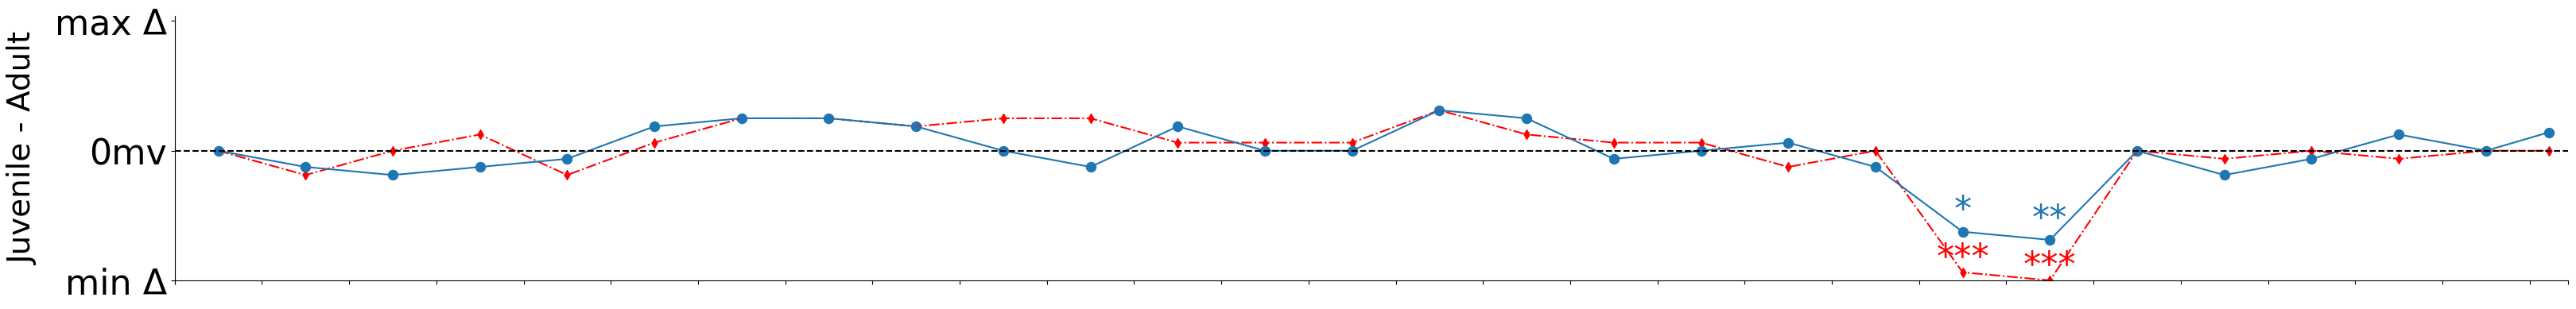

In [50]:
visualiseDiffComparisons([data_f[data_f['Uniprot_ID'] == 'CO1A2_RAT'], data_m[data_m['Uniprot_ID'] == 'CO1A2_RAT']], addRegion=[], save=True)


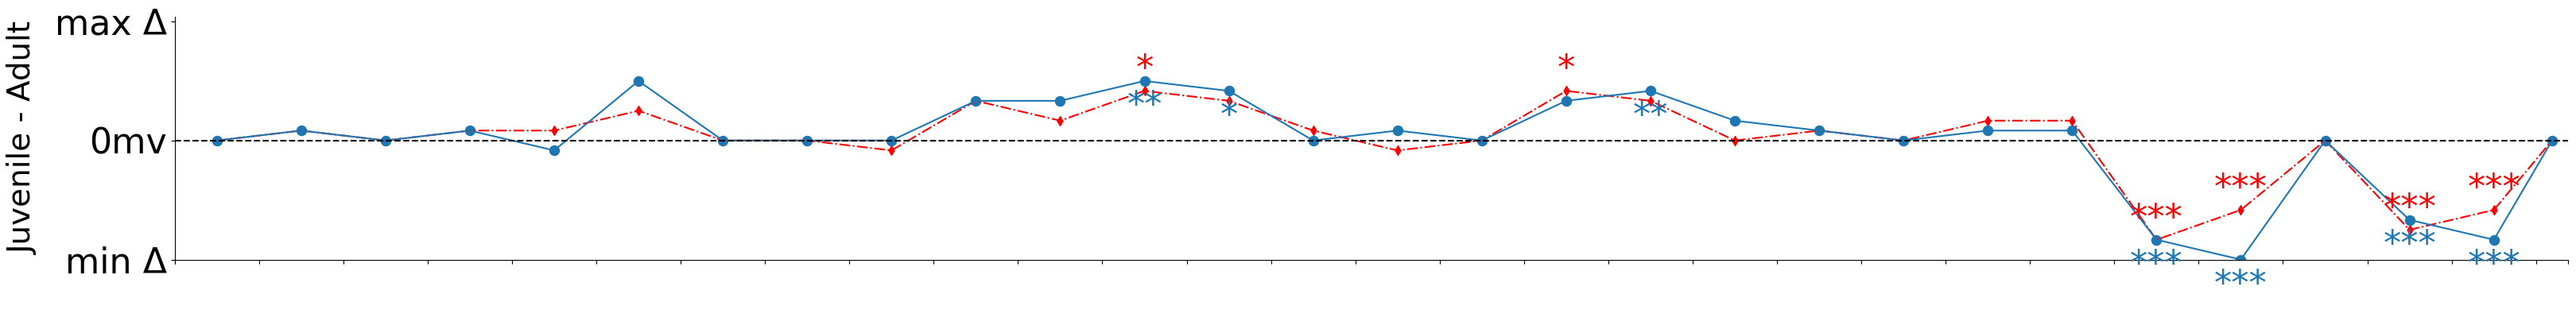

In [61]:
visualiseDiffComparisons([data_f[data_f['Uniprot_ID'] == 'CO2A1_RAT'], data_m[data_m['Uniprot_ID'] == 'CO2A1_RAT']], addRegion=[], save=True)


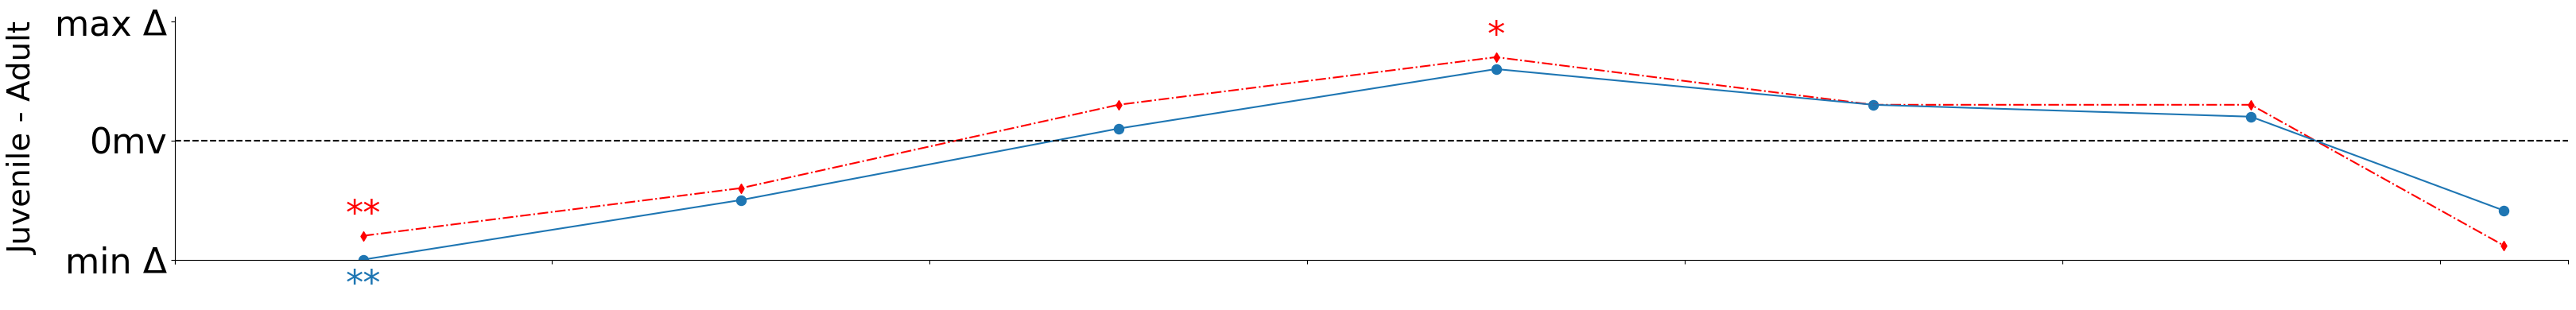

In [62]:
visualiseDiffComparisons([data_f[data_f['Uniprot_ID'] == 'OSTP_RAT'], data_m[data_m['Uniprot_ID'] == 'OSTP_RAT']], addRegion=[], save=True)


Index: 7 | Data name: female | Significance: * | Y: 6 | O: 4 | P_value: 0.0351


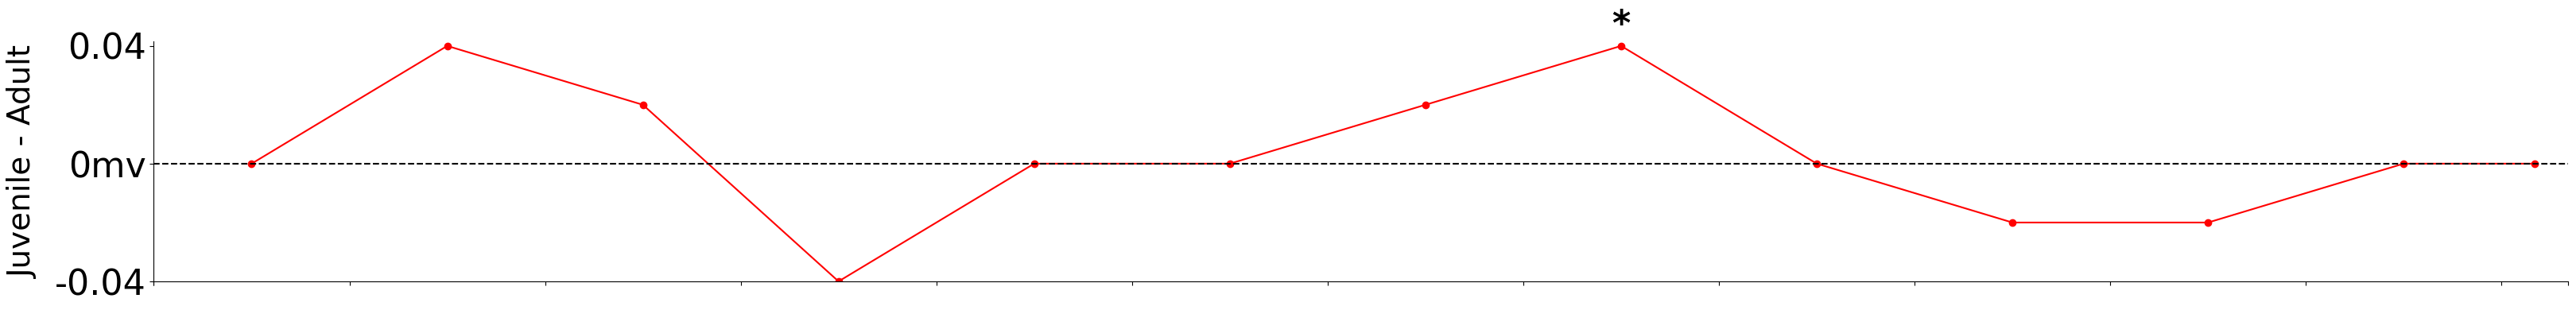

In [63]:
buildDiffGraph(data_f[data_f['Uniprot_ID'] == 'THRB_RAT'], t='female', s='female', addRegion=[], save=True)


In [ ]:
visualiseDiffComparisons([data_f[data_f['Uniprot_ID'] == 'APOE_RAT'], data_m[data_m['Uniprot_ID'] == 'APOE_RAT']], addRegion=[], save=True)
# buildDiffGraph(data_f[data_f['Uniprot_ID'] == 'APOE_RAT'], t='female', s='female', addRegion=[], save=True)
# buildDiffGraph(data_m[data_m['Uniprot_ID'] == 'APOE_RAT'], t='male', s='male', addRegion=[], save=True)

In [ ]:
# buildDiffGraph(data_f[data_f['Uniprot_ID'] == 'COMP_RAT'], t='female', s='female', addRegion=[], save=True)
# buildDiffGraph(data_m[data_m['Uniprot_ID'] == 'COMP_RAT'], t='male', s='male', addRegion=[], save=True)
# visualiseDiffComparisons([data_f[data_f['Uniprot_ID'] == 'COMP_RAT'], data_m[data_m['Uniprot_ID'] == 'COMP_RAT']], addRegion=[], save=True)


In [11]:
# For visualising a single dataset at a time or visualising and comparing 2 datasets
# Takes a list of dataframes that have the same datastructure - column names etc. Will visualise every unique protein in the data
# If comparing 2 dataframes if the protein is present in both datasets then they will be compared
def visualiseAll(data, *args, **kwargs):
    
    sampleGroupNames = kwargs.get('sampleGroupNames', None) # Optional - if there is only one sample group provide list containing lists of strings representing column names
    
    # Defines colour palette to be used for the heatmaps 
    colors = [(1, 1, 1), (1, 0, 0)]  # Transition from white (1, 1, 1) to red (1, 0, 0)
    n_bins = 100  # Number of discrete steps in the colormap
    cmap_name = 'white_to_red'  # Name of the colormap
    cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)
    
    if len(data) == 2:
        data_g1, data_g2 = data
    
        # standardise column names if necessary between datasets
        # data_f.rename(columns={'p: Old vs Young' : 'p: Aged vs Young'}, inplace=True)
        # data_m.rename(columns={'p: Old vs Young' : 'p: Aged vs Young'}, inplace=True)

        # add standard deviation
        femaleGroupSampleNames = [['FZ1_F (ms-status_RAT1)', 'FZ2_F (ms-status_RAT2)', 'FZ3_F (ms-status_RAT3)'], ['JA2_F (ms-status_RAT8)', 'JA5_F (ms-status_RAT11)', 'JA6_F (ms-status_RAT12)']]
        maleGroupSampleNames = [['FZ4_M (ms-status_RAT4)', 'FZ5_M (ms-status_RAT5)', 'FZ6_M (ms-status_RAT6)'], ['JA1_M (ms-status_RAT7)', 'JA3_M (ms-status_RAT9)', 'JA4_M (ms-status_RAT10)']]
        data_g1 = addStandardDeviation(data_g1, femaleGroupSampleNames)
        data_g2 = addStandardDeviation(data_g2, maleGroupSampleNames)

        # find significant proteins in both datasets
        data_f_sig_prots = filterData(data_g1)
        data_m_sig_prots = filterData(data_g2)

        # find significant proteins common to both datasets
        common_proteins = findCommon([data_f_sig_prots, data_m_sig_prots])
        common_sig_proteins = findCommon([data_f_sig_prots, data_m_sig_prots])
        significant_proteins = list(common_sig_proteins['common_to_both']) + list(common_sig_proteins['unique_to_g1']) + list(common_sig_proteins['unique_to_g2'])

        # defines the common proteins
        set1 = set(data_f['Uniprot_ID'])
        set2 = set(data_m['Uniprot_ID'])
        common_prots = set1.intersection(set2)
        common_prots = list(common_prots) # list of common proteins
        data_1 = data_f[data_f['Uniprot_ID'].isin(common_prots)]
        data_2 = data_m[data_m['Uniprot_ID'].isin(common_prots)]
        commonData = [data_1, data_2]

        # define proteins available to male and female datasets
        female = data_f[data_f['Uniprot_ID'].isin(significant_proteins)]
        female = female['Uniprot_ID'].unique()
        male = data_m[data_m['Uniprot_ID'].isin(significant_proteins)]
        male = male['Uniprot_ID'].unique()

        # finds data only present in male dataset
        onlyInMale = set(male) - set(female)
        onlyInMaleData = data_m[data_m['Uniprot_ID'].isin(onlyInMale)]

        # finds data only present in the female dataset
        onlyInFemale = set(female) - set(male)
        onlyInFemaleData = data_f[data_f['Uniprot_ID'].isin(onlyInFemale)]

        # plot graphs for each protein: "Avg peptide spectral counts" | "Avg peptide spectral count differences"
        # if protein is present in both male and female dataset male and female are compared
        for p in significant_proteins:
            if p in common_prots:
                if p in common_proteins['unique_to_g1'] or  p in common_proteins['common_to_both'] :
                    print(p)
                    data = data_f[data_f['Uniprot_ID'] == p]
                    BuildGraph(data, g='Average Young', t='young female')
                    BuildGraph(data, g='Average Old', t='old female')
                if p in common_proteins['unique_to_g2'] or p in common_proteins['common_to_both'] :
                    print(p)
                    data = data_m[data_m['Uniprot_ID'] == p]
                    BuildGraph(data, g='Average Young', t='young male')
                    BuildGraph(data, g='Average Old', t='old male')
                data = [data_f[data_f['Uniprot_ID'] == p], data_m[data_m['Uniprot_ID'] == p]]
                visualiseDiffComparisons(data)
                print('---' * 100)
            elif p in onlyInFemale:
                print(p)
                data = data_f[data_f['Uniprot_ID'] == p]
                BuildGraph(data, g='Average Young', t='young female')
                BuildGraph(data, g='Average Old', t='old female')
                buildDiffGraph(data, t='female')
                print('---' * 100)
            else:
                print(p)
                data = data_m[data_m['Uniprot_ID'] == p]
                BuildGraph(data, g='Average Young', t='young male')
                BuildGraph(data, g='Average Old', t='old male')
                buildDiffGraph(data, t='male')
                print('---' * 100)
    
    # If there is only 1 dataset run else        
    else:
        d = data[0]
        
        d = addStandardDeviation(d, sampleGroupNames) # add standard deviation
        
        significant_proteins = filterData(d) # filter for proteins with at least 1 significant region of PSM difference
        
        for p in significant_proteins:
            data = d[d['Uniprot_ID'] == p]
            BuildGraph(data, g='Average Young')
            BuildGraph(data, g='Average Old')
            buildDiffGraph(data)
    
    # data for difference comparison graphs
    # data = [data_f[data_f['Uniprot_ID'].isin(significant_proteins)], data_m[data_m['Uniprot_ID'].isin(significant_proteins)]]


In [12]:
# Running visualise all on two datasets
# visualiseAll([data_f, data_m])

In [13]:
# Example of running visualise all for 1 dataset
# GSN = [['FZ1_F (ms-status_RAT1)', 'FZ2_F (ms-status_RAT2)', 'FZ3_F (ms-status_RAT3)'], ['JA2_F (ms-status_RAT8)', 'JA5_F (ms-status_RAT11)', 'JA6_F (ms-status_RAT12)']]
# visualiseAll([data_f], sampleGroupNames = GSN)

In [39]:
# data_f[data_f['Uniprot_ID'] == 'CO1A1_RAT']

C:\Users\jtudo\AppData\Local\Temp\ipykernel_15404\4132237695.py:113: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


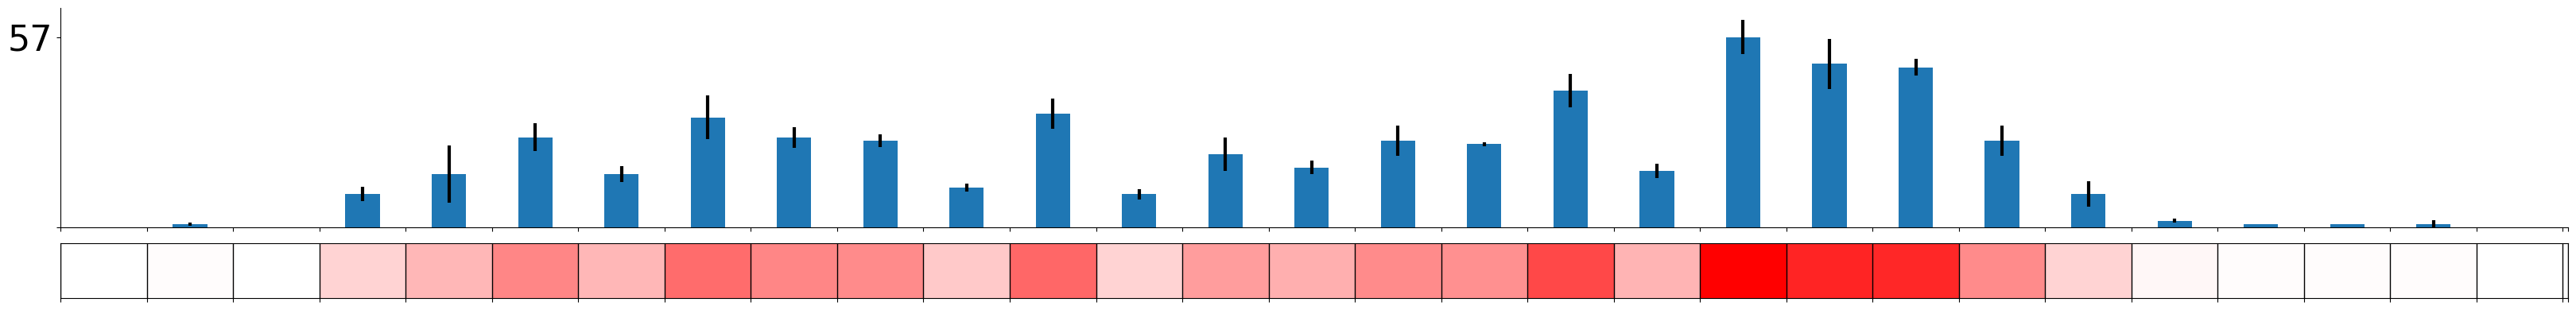

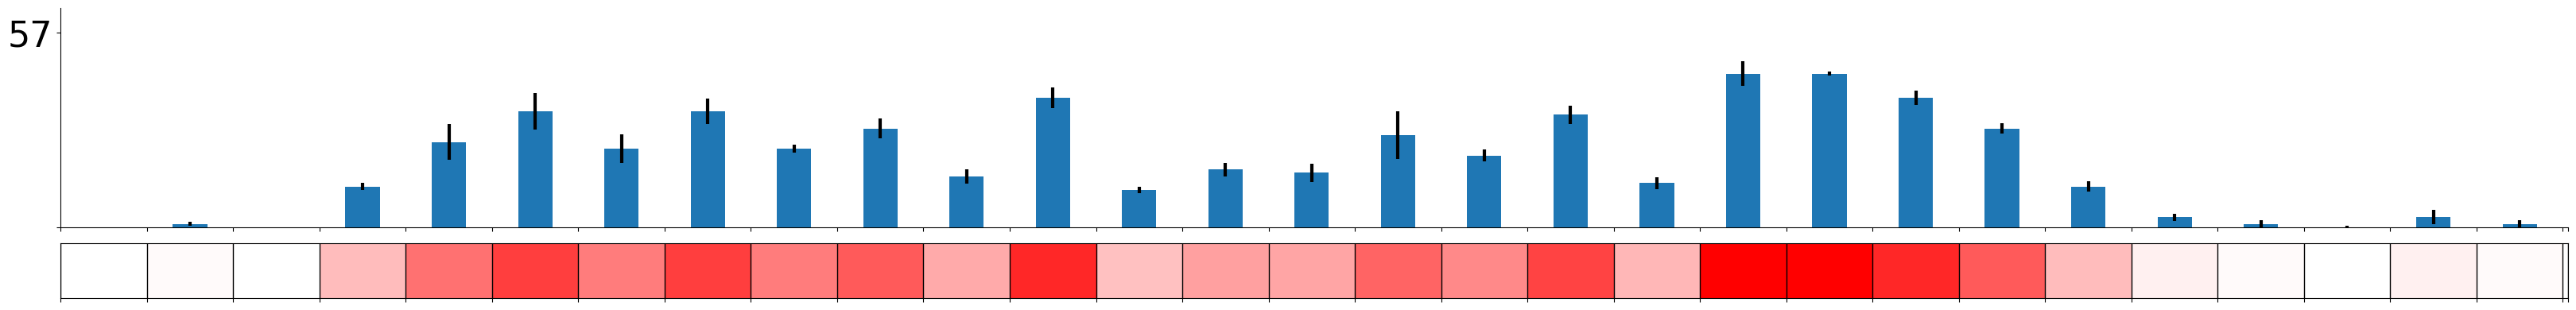

Index: 4 | Data name: female | Significance: * | Y: 16 | O: 25 | P_value: 0.015
Index: 19 | Data name: female | Significance: *** | Y: 57 | O: 45 | P_value: 0.0
Index: 21 | Data name: female | Significance: * | Y: 48 | O: 38 | P_value: 0.015


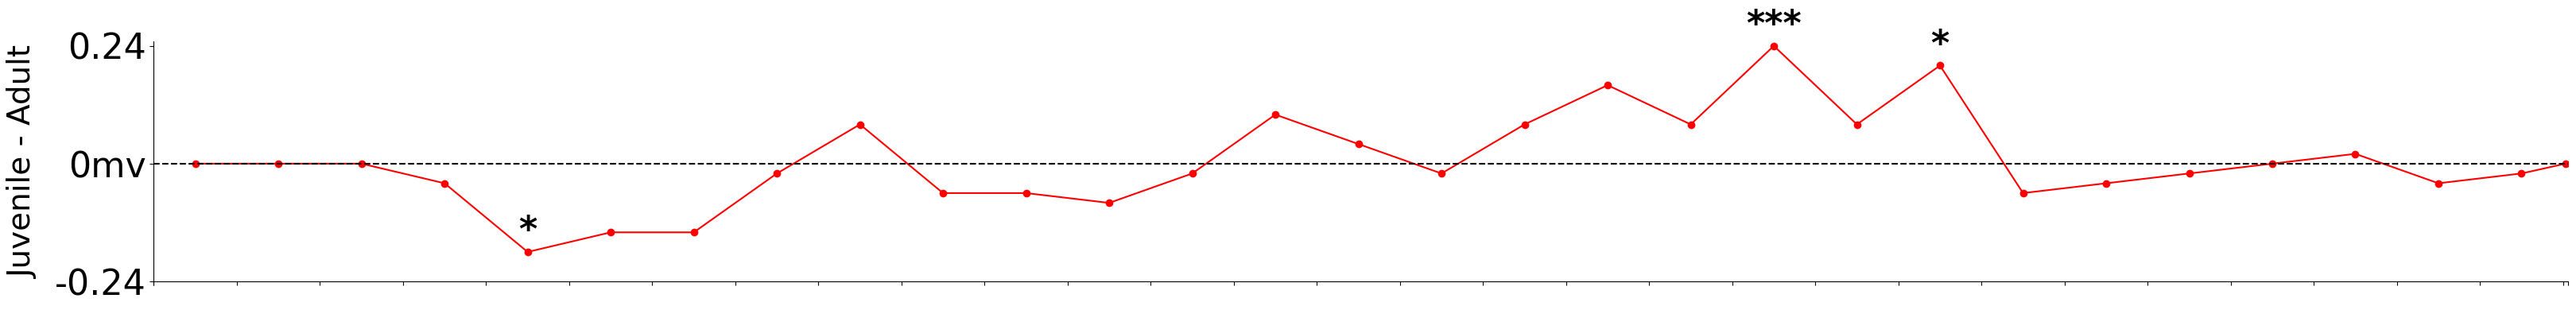

In [35]:
BuildGraph(data_f[data_f['Uniprot_ID'] == 'CO1A1_RAT'], g='Average Young', age='fuzzy', s='female', scale=57, save=True)
BuildGraph(data_f[data_f['Uniprot_ID'] == 'CO1A1_RAT'], g='Average Old', age='jumbo', s='female', scale=57, save=True)

buildDiffGraph(data_f[data_f['Uniprot_ID'] == 'CO1A1_RAT'], t='female', addRegion=[], save=True)
# buildDiffGraph(data_f[data_f['Uniprot_ID'] == 'CO1A1_RAT'], t='female', addRegion=[('NC1-start', 1208, 'center', 0.01, 'orange'), ('N-term-End', 151, 'center', 0.01, 'orange')])

C:\Users\jtudo\AppData\Local\Temp\ipykernel_15404\4132237695.py:113: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


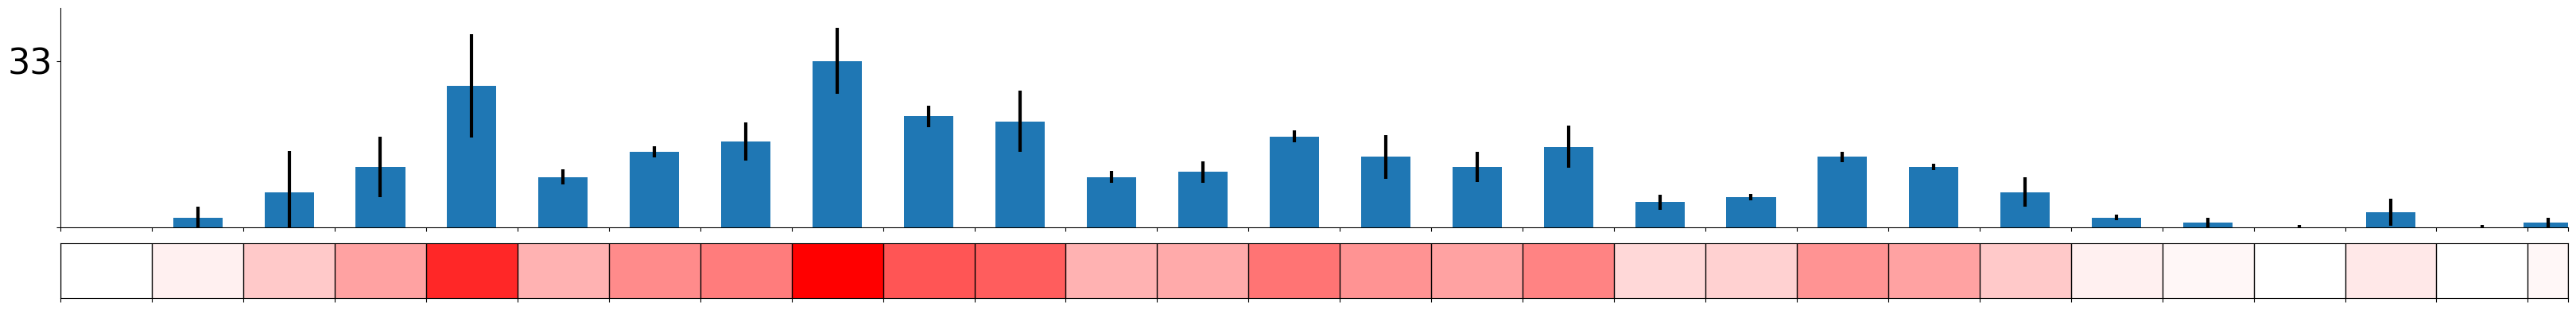

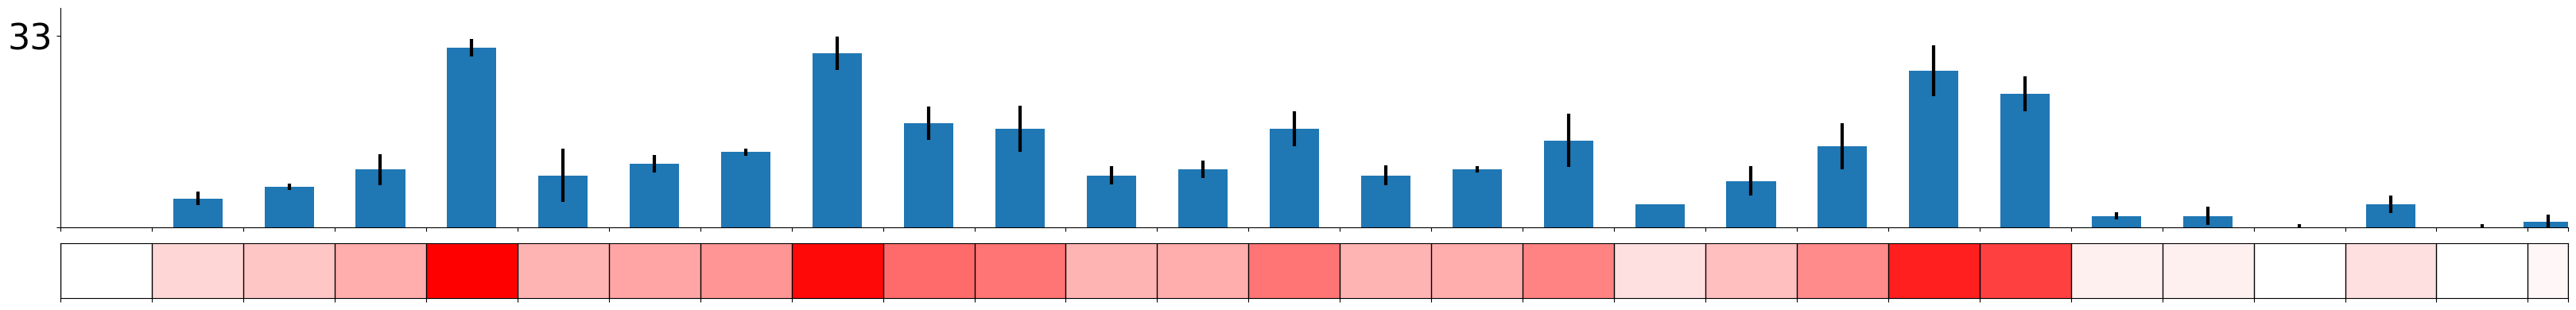

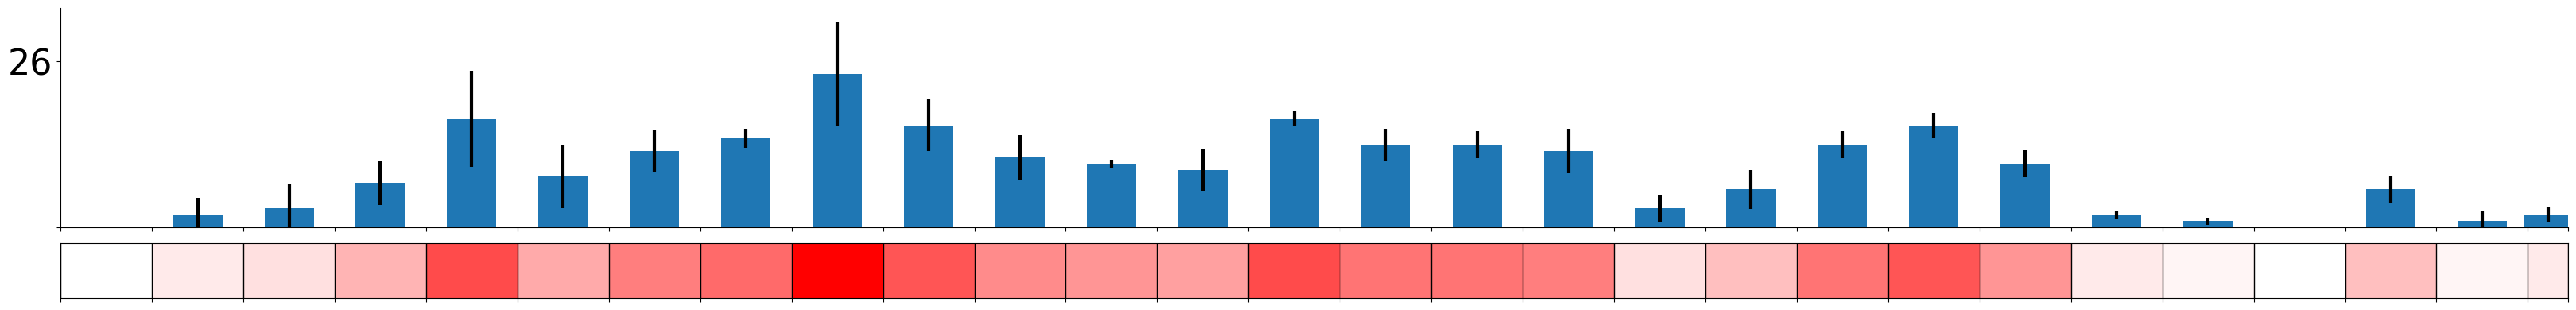

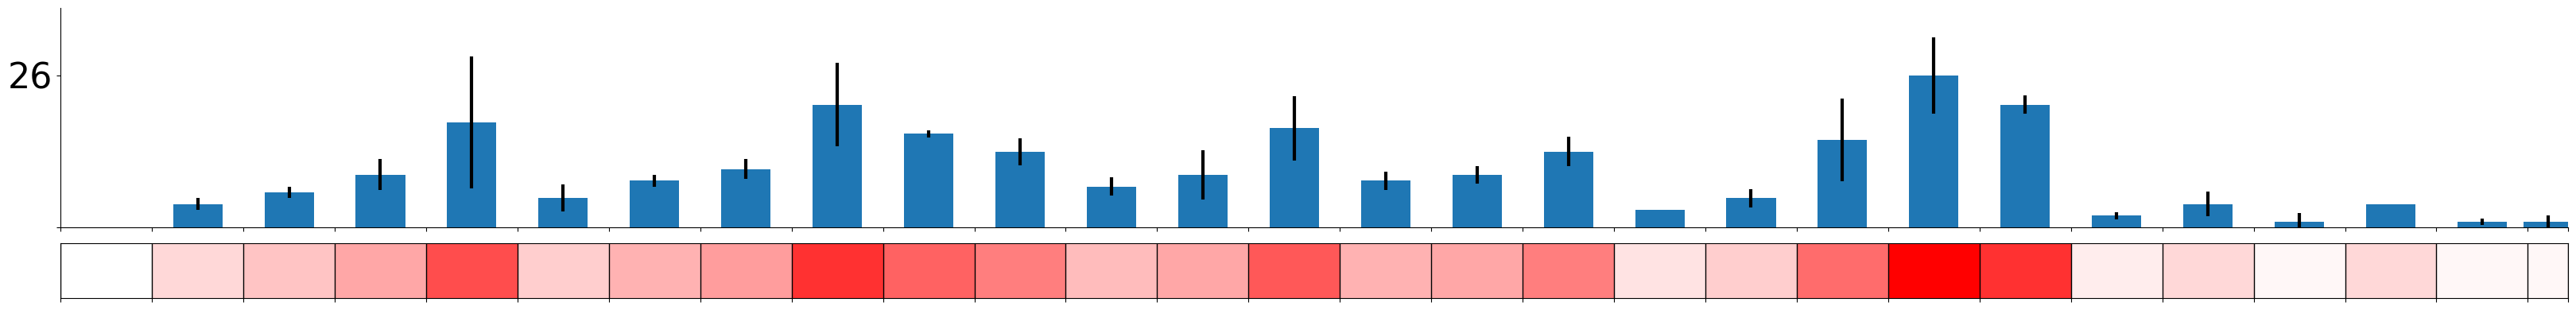

Index: 20 | Data name: female | Significance: *** | Y: 12 | O: 27 | P_value: 0.0
Index: 21 | Data name: female | Significance: *** | Y: 7 | O: 23 | P_value: 0.0


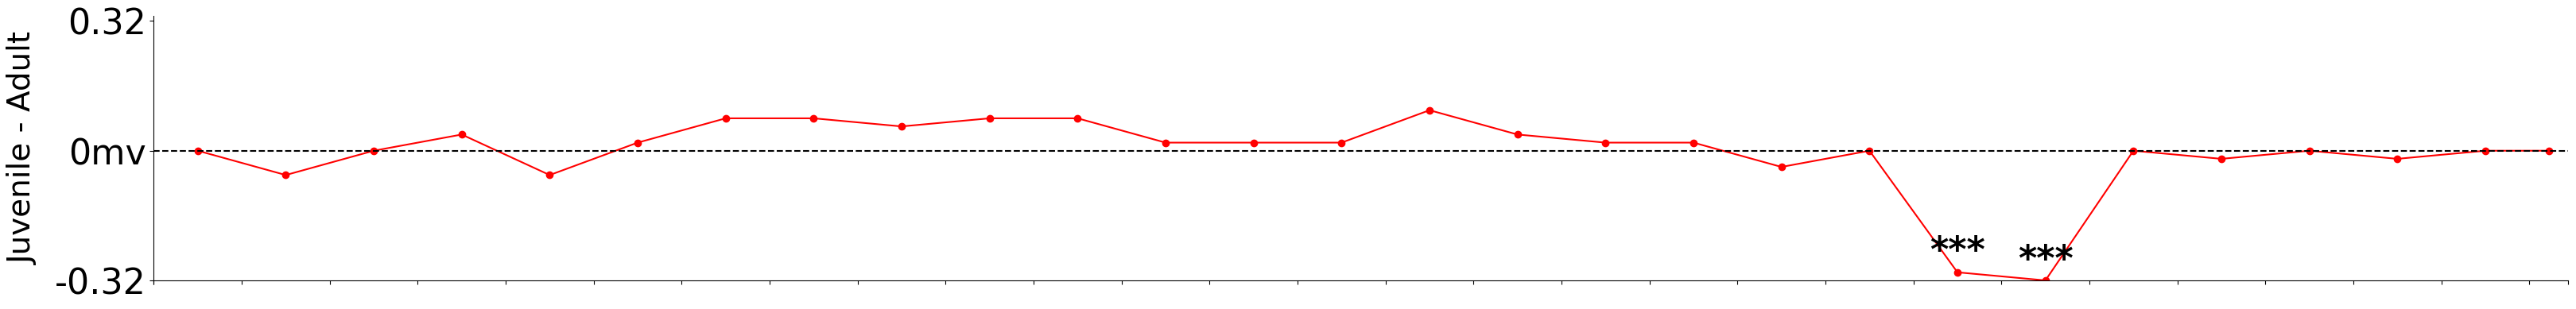

Index: 20 | Data name: male | Significance: * | Y: 16 | O: 26 | P_value: 0.0224
Index: 21 | Data name: male | Significance: ** | Y: 10 | O: 21 | P_value: 0.0084


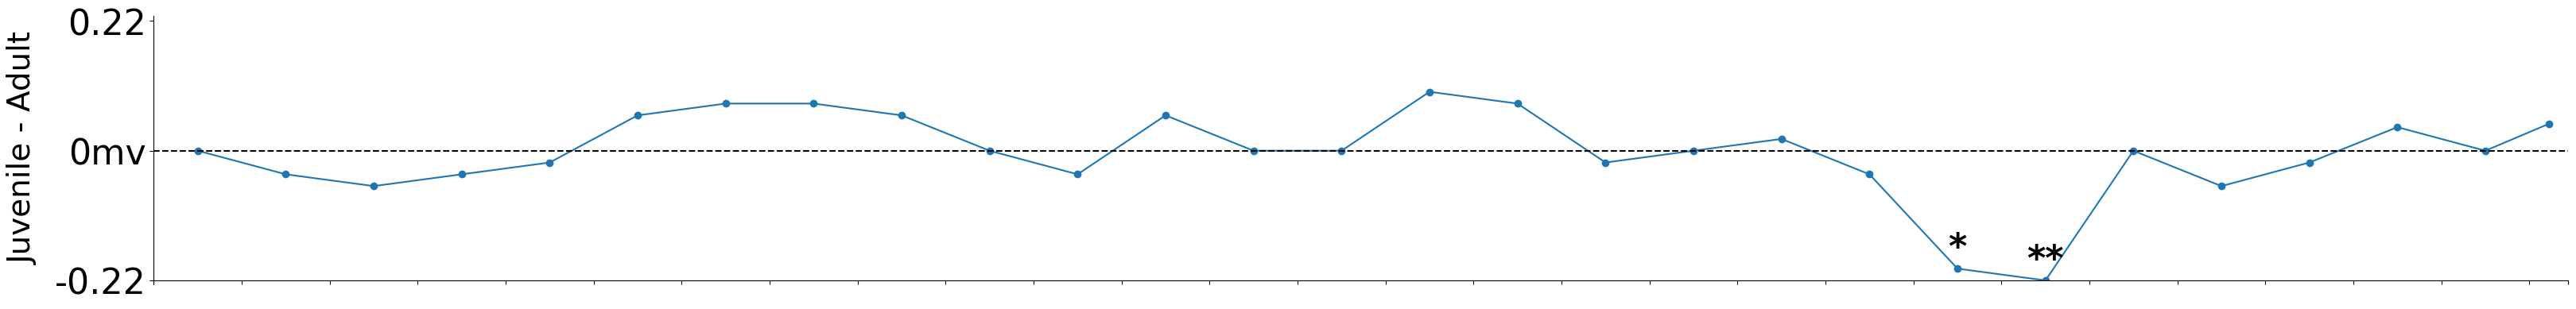

sig ***
Index: 20 | Data name: data_1 | Significance: *** | Y: 12 | O: 27 | Diff: -0.3 | P_value: 0.0
sig ***
Index: 21 | Data name: data_1 | Significance: *** | Y: 7 | O: 23 | Diff: -0.32 | P_value: 0.0
sig *
Index: 20 | Data name: data_2 | Significance: * | Y: 16 | O: 26 | Diff: -0.2 | P_value: 0.0224
sig **
Index: 21 | Data name: data_2 | Significance: ** | Y: 10 | O: 21 | Diff: -0.22 | P_value: 0.0084


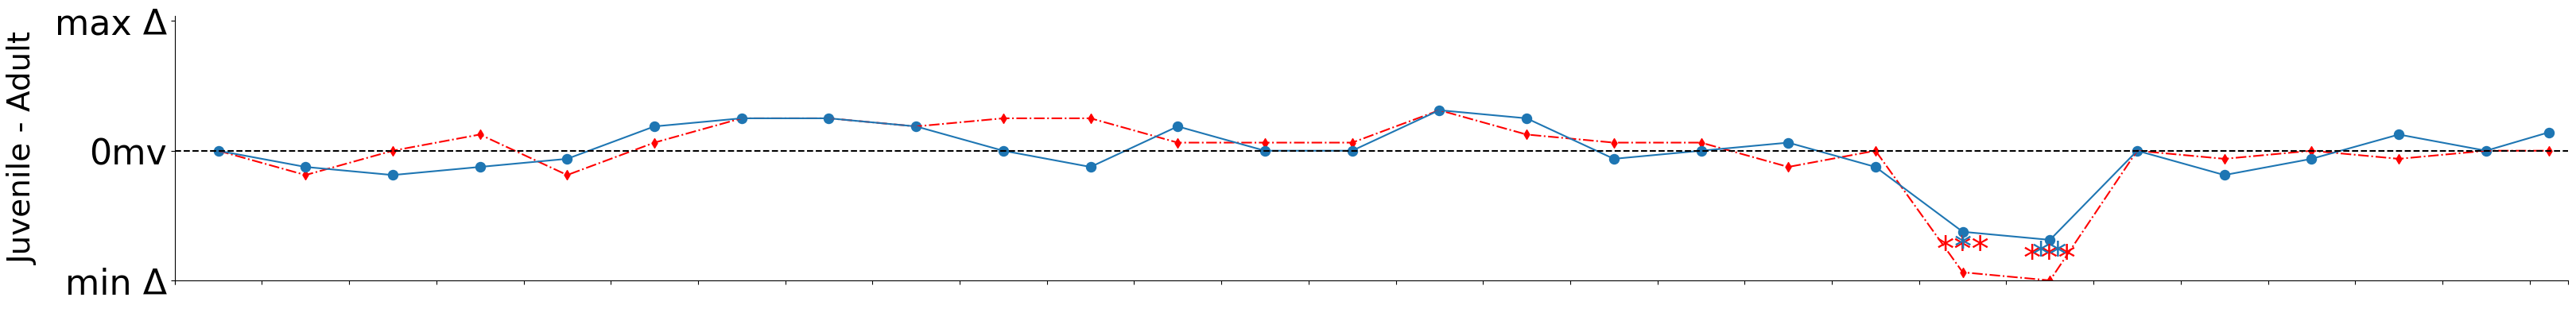

In [32]:
BuildGraph(data_f[data_f['Uniprot_ID'] == 'CO1A2_RAT'], g='Average Young', age='fuzzy', s='female', scale=33, save=True)
BuildGraph(data_f[data_f['Uniprot_ID'] == 'CO1A2_RAT'], g='Average Old', age='jumbo', s='female', scale=33, save=True)
BuildGraph(data_m[data_m['Uniprot_ID'] == 'CO1A2_RAT'], g='Average Young', age='fuzzy', s='male', scale=26, save=True)
BuildGraph(data_m[data_m['Uniprot_ID'] == 'CO1A2_RAT'], g='Average Old', age='jumbo', s='male', scale=26, save=True)

buildDiffGraph(data_f[data_f['Uniprot_ID'] == 'CO1A2_RAT'], t='female', s='female', addRegion=[], save=True)
buildDiffGraph(data_m[data_m['Uniprot_ID'] == 'CO1A2_RAT'], t='male', s='male', addRegion=[], save=True)

visualiseDiffComparisons([data_f[data_f['Uniprot_ID'] == 'CO1A2_RAT'], data_m[data_m['Uniprot_ID'] == 'CO1A2_RAT']], addRegion=[], save=True)
# visualiseDiffComparisons([data_f[data_f['Uniprot_ID'] == 'CO1A2_RAT'], data_m[data_m['Uniprot_ID'] == 'CO1A2_RAT']], addRegion=[('NC1-start', 1126, 'center', 0.001)])

In [ ]:
visualiseDiffComparisons([data_f[data_f['Uniprot_ID'] == 'CO1A2_RAT'], data_m[data_m['Uniprot_ID'] == 'CO1A2_RAT']], addRegion=[], save=True)

In [ ]:
## 

C:\Users\jtudo\AppData\Local\Temp\ipykernel_15404\4132237695.py:113: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


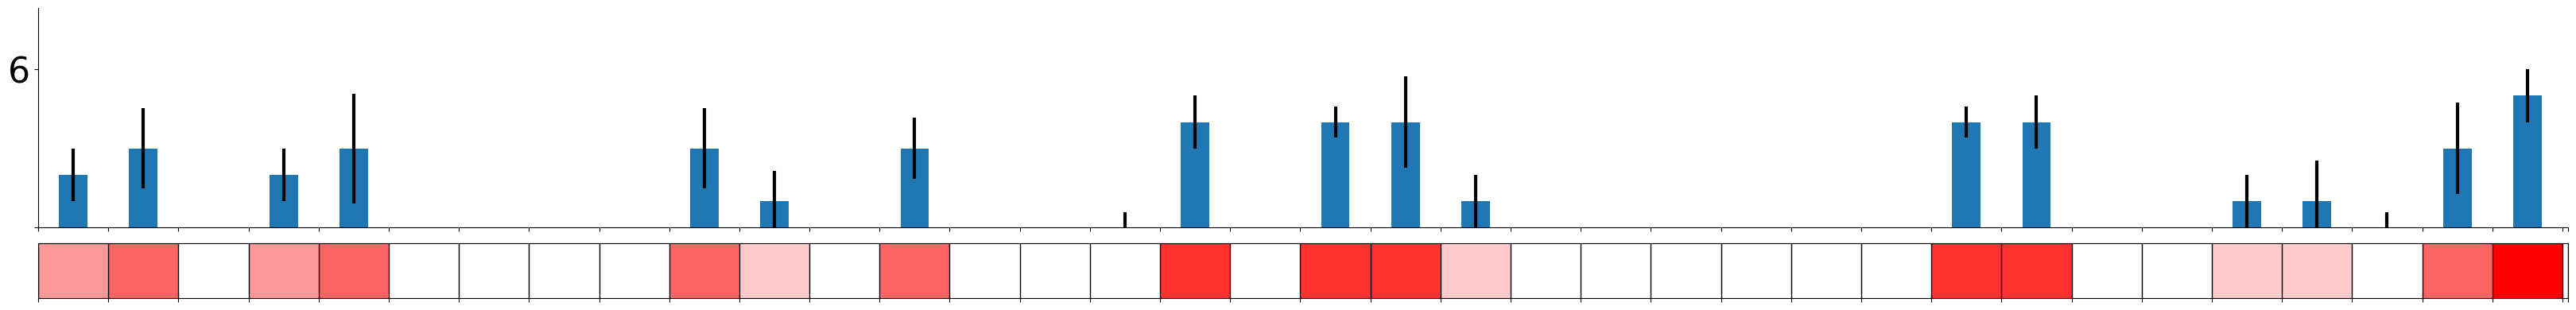

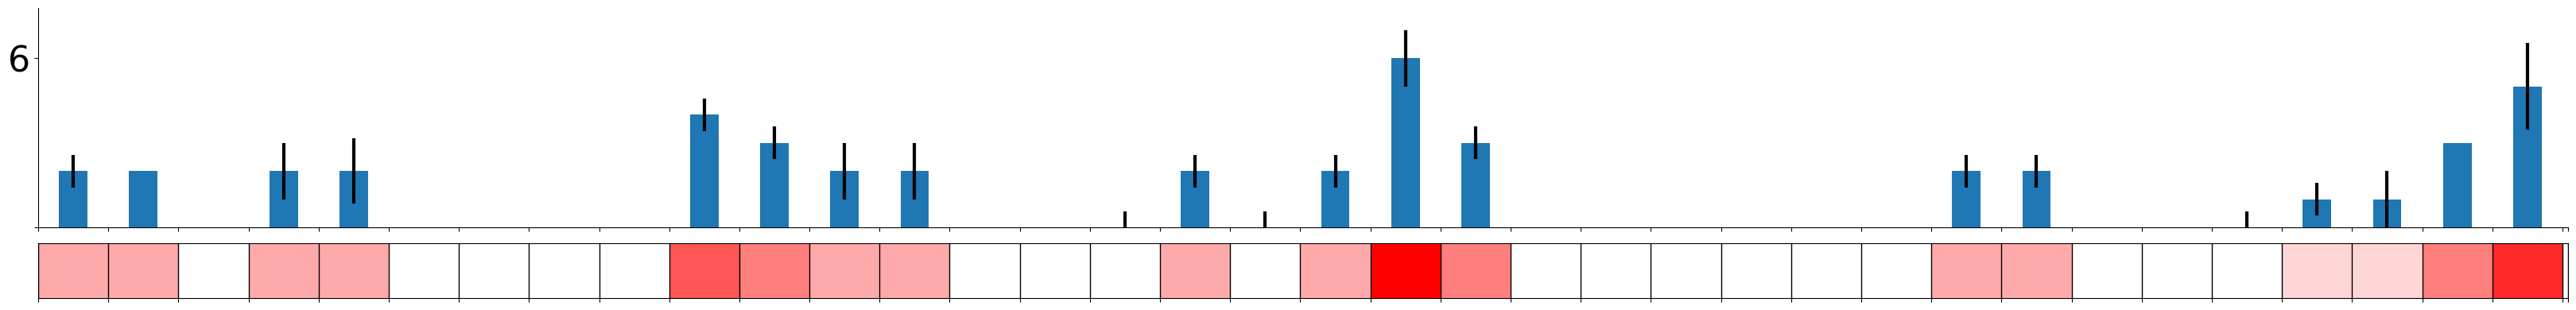

In [33]:
BuildGraph(data_m[data_m['Uniprot_ID'] == 'COBA1_RAT'], g='Average Young', age='fuzzy', s='male', scale=6, save=True)
BuildGraph(data_m[data_m['Uniprot_ID'] == 'COBA1_RAT'], g='Average Old', age='jumbo', s='male', scale=6, save=True)

# buildDiffGraph(data_m[data_m['Uniprot_ID'] == 'COBA1_RAT'], t='male', s='male', addRegion=[], save=True)

# buildDiffGraph(data_m[data_m['Uniprot_ID'] == 'COBA1_RAT'], t='male', addRegion=[])

C:\Users\jtudo\AppData\Local\Temp\ipykernel_15404\4132237695.py:113: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


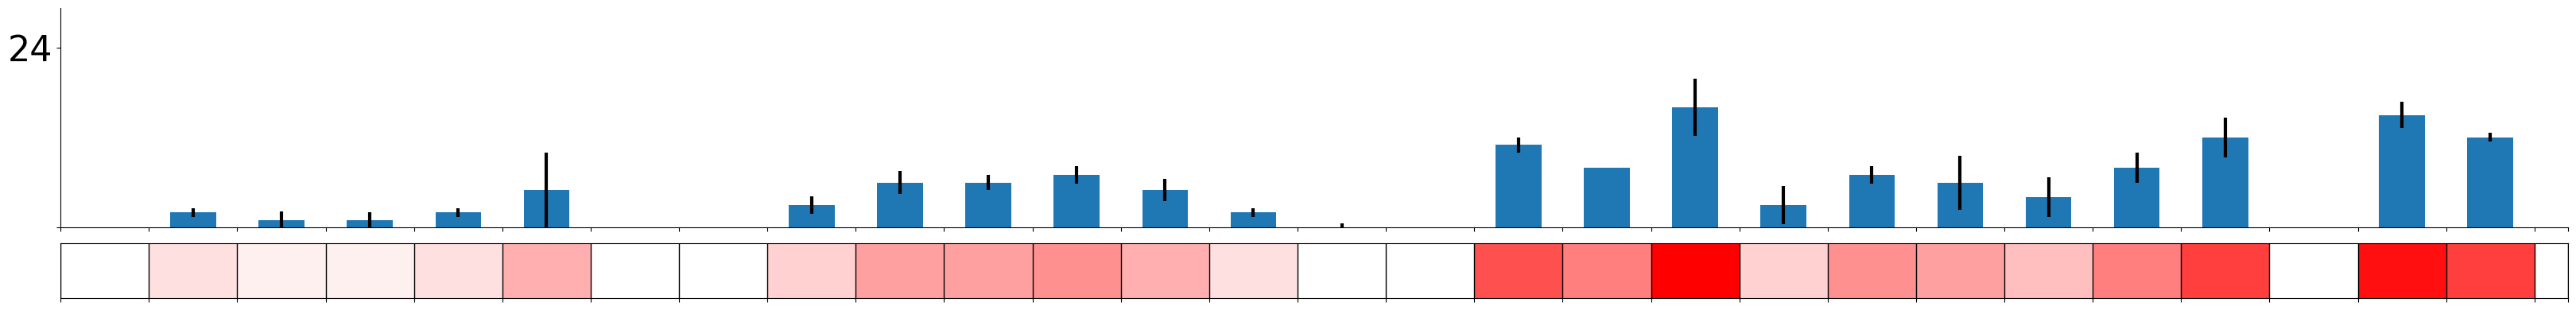

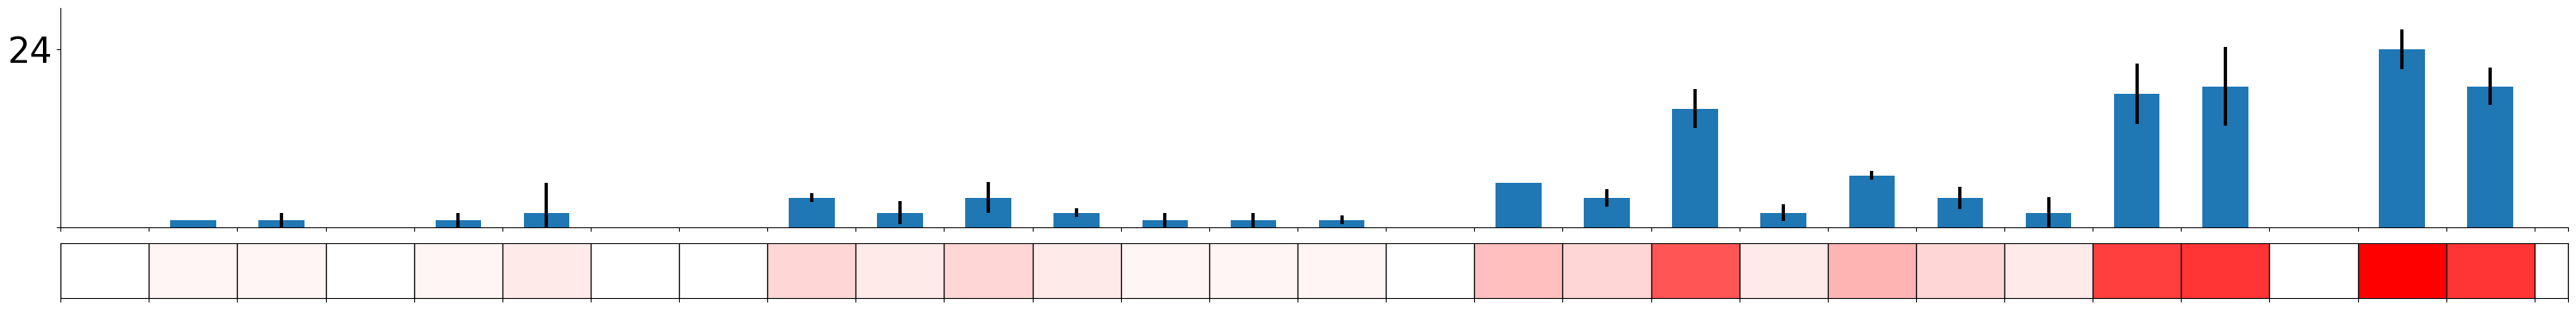

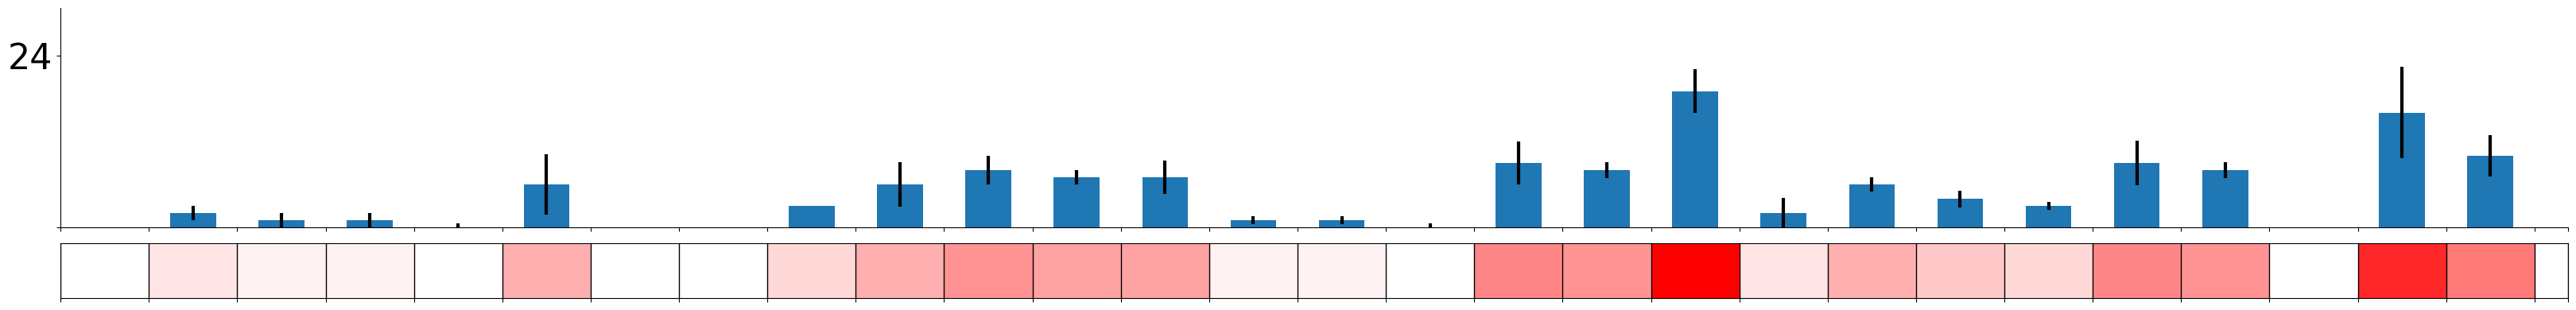

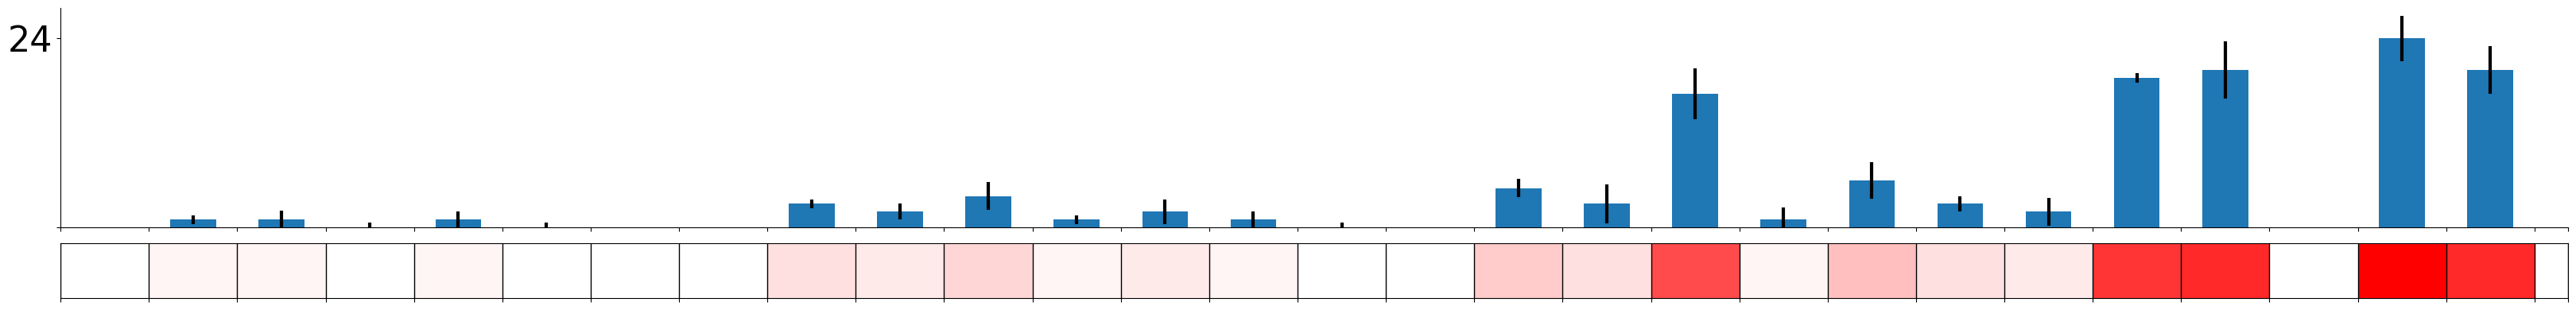

Index: 11 | Data name: female | Significance: * | Y: 7 | O: 2 | P_value: 0.0348
Index: 16 | Data name: female | Significance: * | Y: 11 | O: 6 | P_value: 0.0348
Index: 23 | Data name: female | Significance: *** | Y: 8 | O: 18 | P_value: 0.0
Index: 24 | Data name: female | Significance: *** | Y: 12 | O: 19 | P_value: 0.0
Index: 26 | Data name: female | Significance: *** | Y: 15 | O: 24 | P_value: 0.0
Index: 27 | Data name: female | Significance: *** | Y: 12 | O: 19 | P_value: 0.0


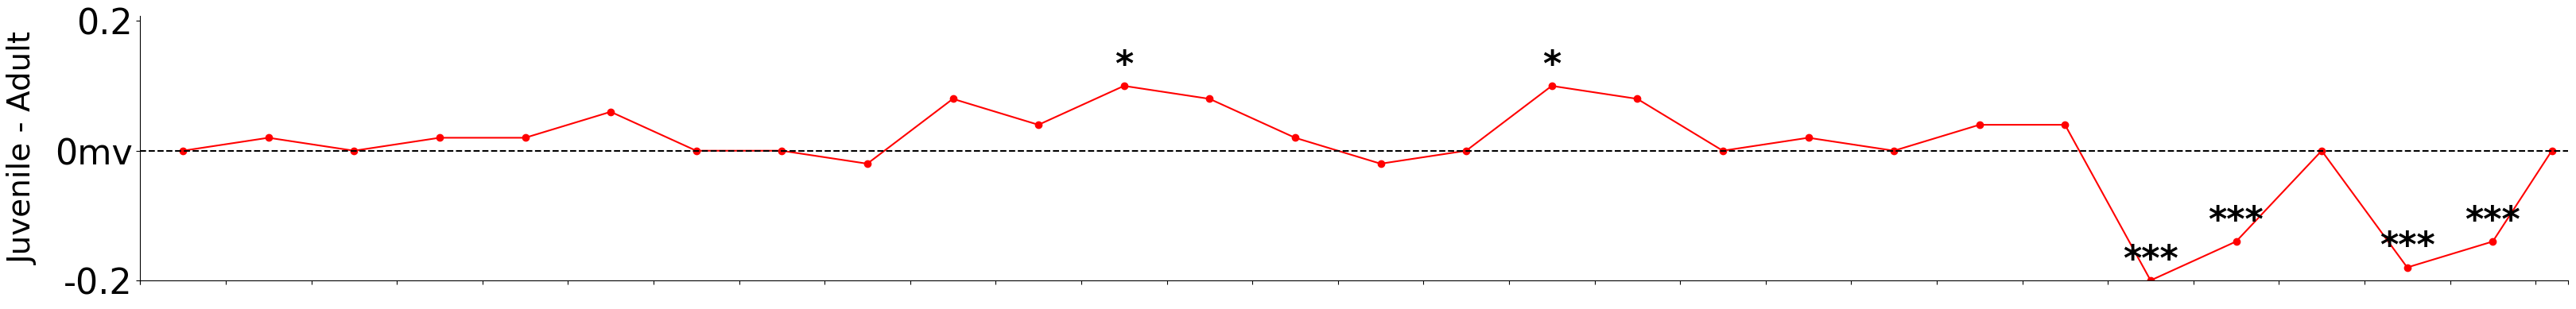

Index: 11 | Data name: male | Significance: ** | Y: 7 | O: 1 | P_value: 0.0087
Index: 12 | Data name: male | Significance: * | Y: 7 | O: 2 | P_value: 0.0377
Index: 17 | Data name: male | Significance: ** | Y: 8 | O: 3 | P_value: 0.0087
Index: 23 | Data name: male | Significance: *** | Y: 9 | O: 19 | P_value: 0.0
Index: 24 | Data name: male | Significance: *** | Y: 8 | O: 20 | P_value: 0.0
Index: 26 | Data name: male | Significance: *** | Y: 16 | O: 24 | P_value: 0.0
Index: 27 | Data name: male | Significance: *** | Y: 10 | O: 20 | P_value: 0.0


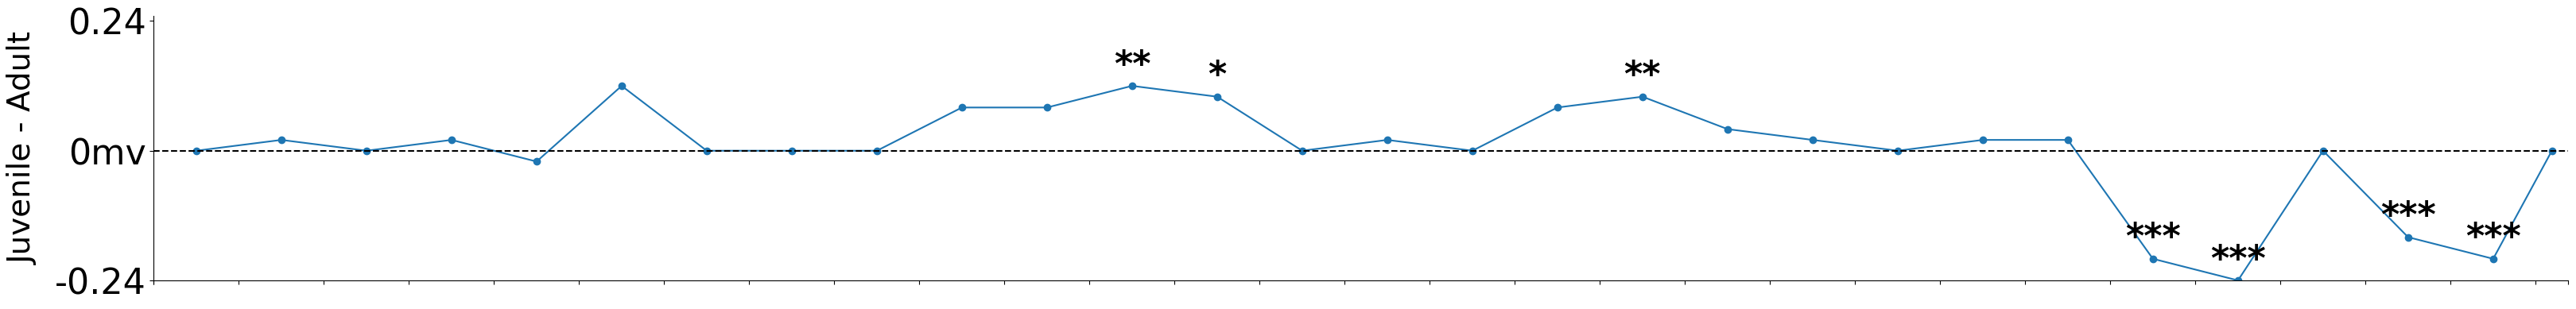

sig *
Index: 11 | Data name: data_1 | Significance: * | Y: 7 | O: 2 | Diff: 0.1 | P_value: 0.0348
sig *
Index: 16 | Data name: data_1 | Significance: * | Y: 11 | O: 6 | Diff: 0.1 | P_value: 0.0348
sig ***
Index: 23 | Data name: data_1 | Significance: *** | Y: 8 | O: 18 | Diff: -0.2 | P_value: 0.0
sig ***
Index: 24 | Data name: data_1 | Significance: *** | Y: 12 | O: 19 | Diff: -0.14 | P_value: 0.0
sig ***
Index: 26 | Data name: data_1 | Significance: *** | Y: 15 | O: 24 | Diff: -0.18 | P_value: 0.0
sig ***
Index: 27 | Data name: data_1 | Significance: *** | Y: 12 | O: 19 | Diff: -0.14 | P_value: 0.0
sig **
Index: 11 | Data name: data_2 | Significance: ** | Y: 7 | O: 1 | Diff: 0.12 | P_value: 0.0087
sig *
Index: 12 | Data name: data_2 | Significance: * | Y: 7 | O: 2 | Diff: 0.1 | P_value: 0.0377
sig **
Index: 17 | Data name: data_2 | Significance: ** | Y: 8 | O: 3 | Diff: 0.1 | P_value: 0.0087
sig ***
Index: 23 | Data name: data_2 | Significance: *** | Y: 9 | O: 19 | Diff: -0.2 | P_valu

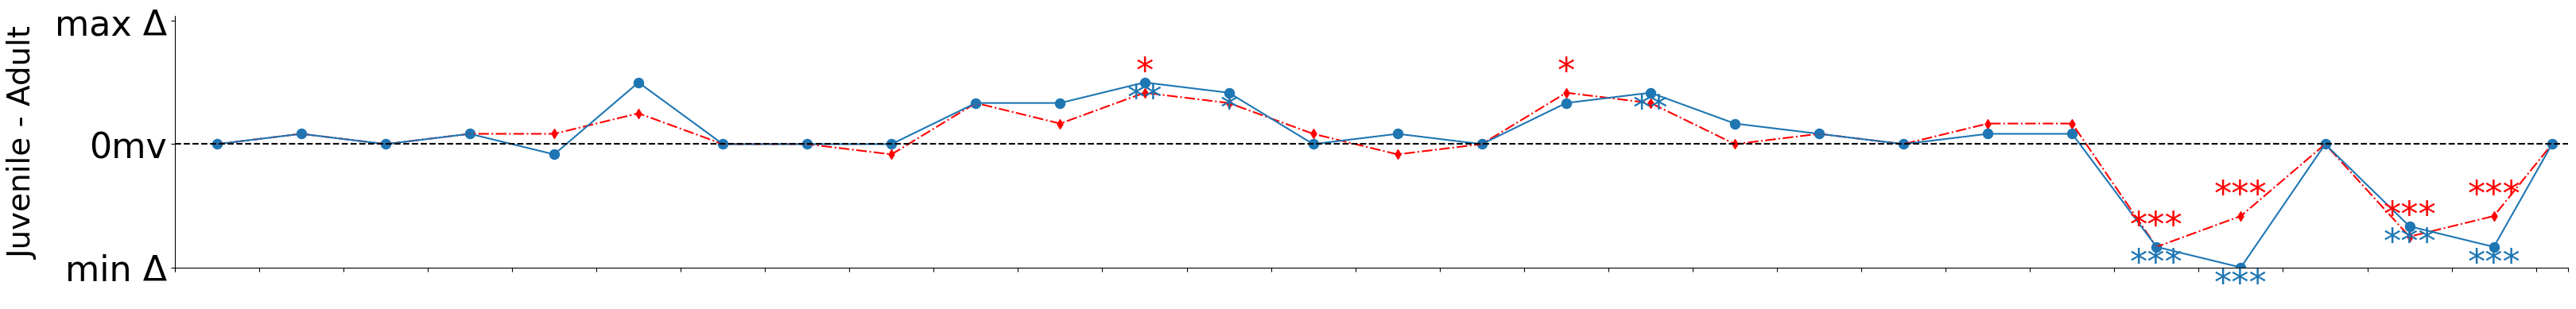

In [34]:
BuildGraph(data_f[data_f['Uniprot_ID'] == 'CO2A1_RAT'], g='Average Young', age='fuzzy', s='female', scale=24, save=True)
BuildGraph(data_f[data_f['Uniprot_ID'] == 'CO2A1_RAT'], g='Average Old', age='jumbo', s='female', scale=24, save=True)
BuildGraph(data_m[data_m['Uniprot_ID'] == 'CO2A1_RAT'], g='Average Young', age='fuzzy', s='male', scale=24, save=True)
BuildGraph(data_m[data_m['Uniprot_ID'] == 'CO2A1_RAT'], g='Average Old', age='jumbo', s='male', scale=24, save=True)

buildDiffGraph(data_f[data_f['Uniprot_ID'] == 'CO2A1_RAT'], t='female', s='female', addRegion=[], save=True)
buildDiffGraph(data_m[data_m['Uniprot_ID'] == 'CO2A1_RAT'], t='male', s='male', addRegion=[], save=True)

visualiseDiffComparisons([data_f[data_f['Uniprot_ID'] == 'CO2A1_RAT'], data_m[data_m['Uniprot_ID'] == 'CO2A1_RAT']], addRegion=[], save=True)
# visualiseDiffComparisons([data_f[data_f['Uniprot_ID'] == 'CO2A1_RAT'], data_m[data_m['Uniprot_ID'] == 'CO2A1_RAT']], addRegion=[('Chain-start', 114, 'center', 0.001), ('NC1-start', 1173, 'center', 0.001)])

C:\Users\jtudo\AppData\Local\Temp\ipykernel_40828\3155399219.py:113: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


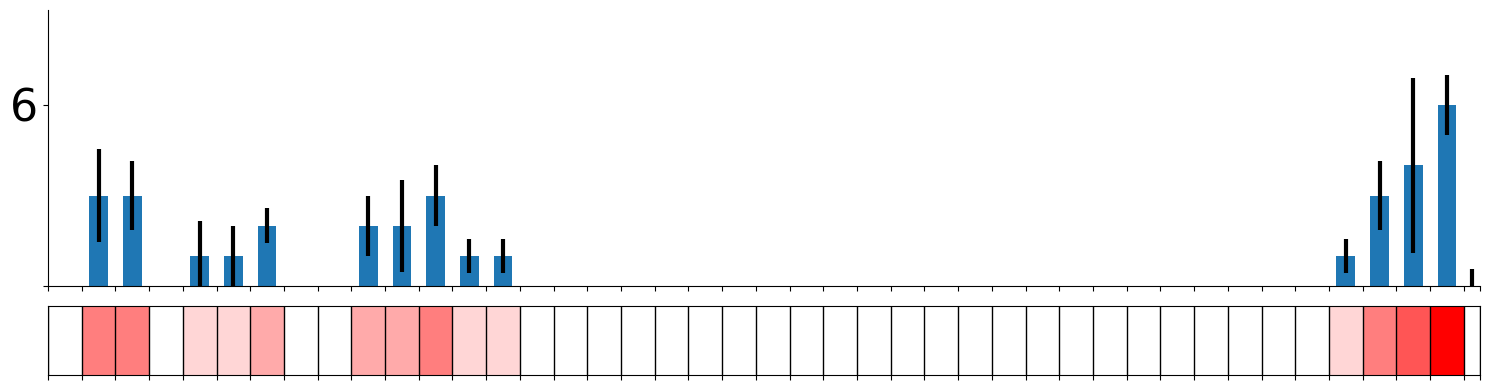

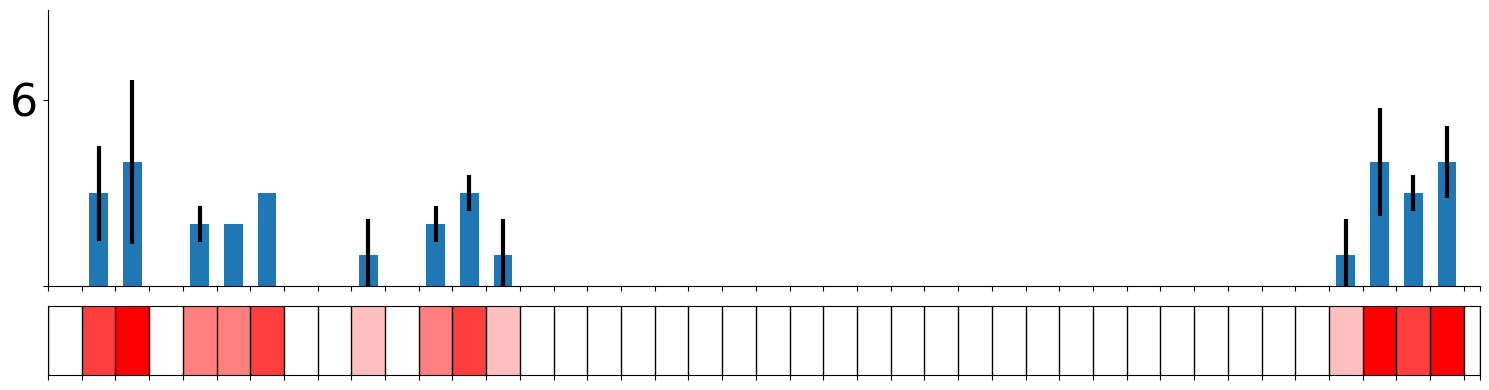

In [35]:
BuildGraph(data_f[data_f['Uniprot_ID'] == 'PGCA_RAT'], g='Average Young', age='fuzzy', s='female', scale=6, save=True)
BuildGraph(data_f[data_f['Uniprot_ID'] == 'PGCA_RAT'], g='Average Old', age='jumbo', s='female', scale=6, save=True)

# buildDiffGraph(data_f[data_f['Uniprot_ID'] == 'PGCA_RAT'], t='female', s='female', addRegion=[], save=True)
# buildDiffGraph(data_m[data_m['Uniprot_ID'] == 'PGCA_RAT'], t='male', s='male', addRegion=[], save=True)

# visualiseDiffComparisons([data_f[data_f['Uniprot_ID'] == 'PGCA_RAT'], data_m[data_m['Uniprot_ID'] == 'PGCA_RAT']], addRegion=[], save=True)
# visualiseDiffComparisons([data_f[data_f['Uniprot_ID'] == 'PGCA_RAT'], data_m[data_m['Uniprot_ID'] == 'PGCA_RAT']], addRegion=[('Link_4-start', 588, 'center', 0.001), ('Link_4-end', 684, 'center', -0.0015), ('KS-start', 685, 'center', -0.004), ('KS-end', 798, 'center', -0.006)])

C:\Users\jtudo\AppData\Local\Temp\ipykernel_4280\1529429153.py:113: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


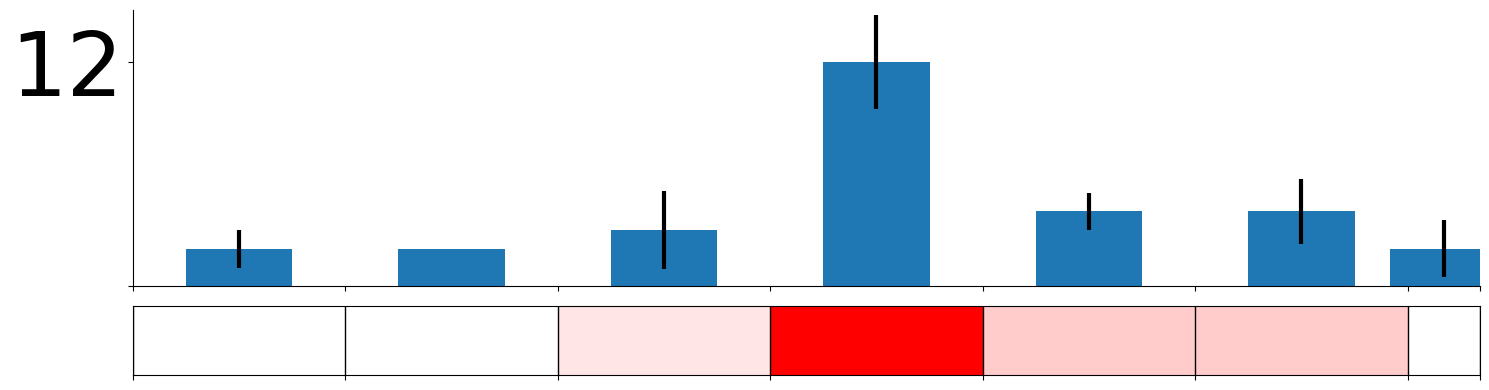

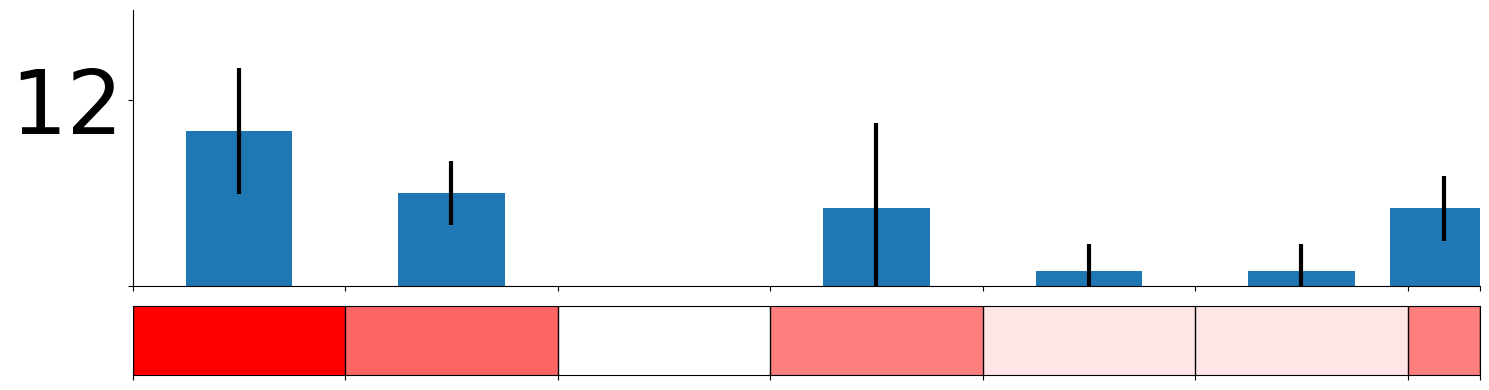

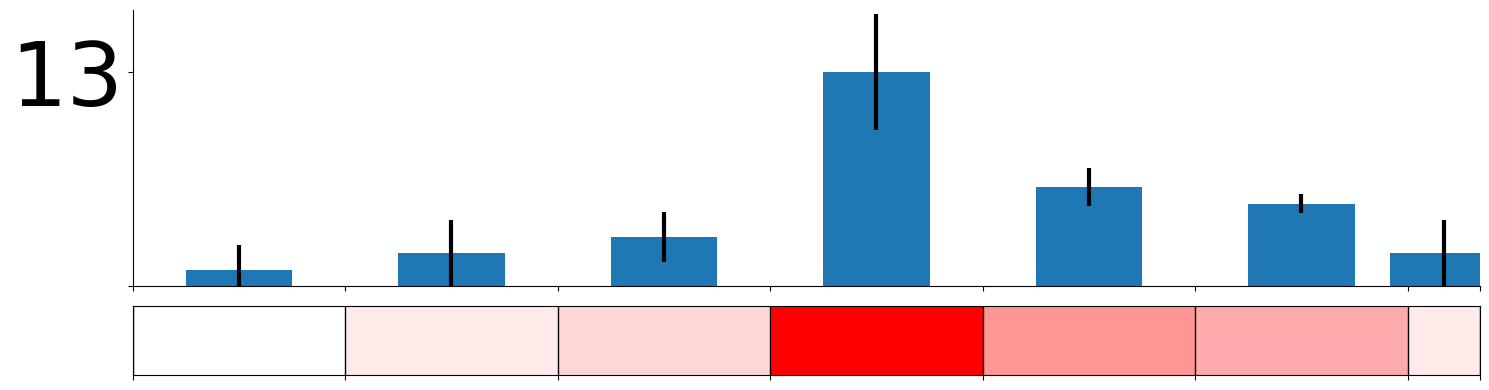

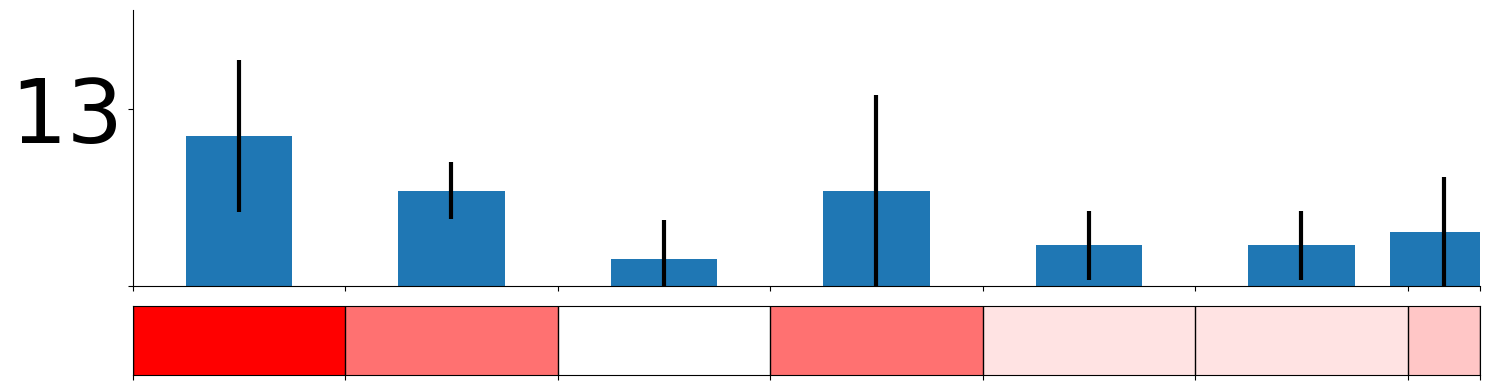

Index: 0 | Data name: female | Significance: ** | Y: 2 | O: 10 | P_value: 0.0014
Index: 3 | Data name: female | Significance: * | Y: 12 | O: 5 | P_value: 0.0203


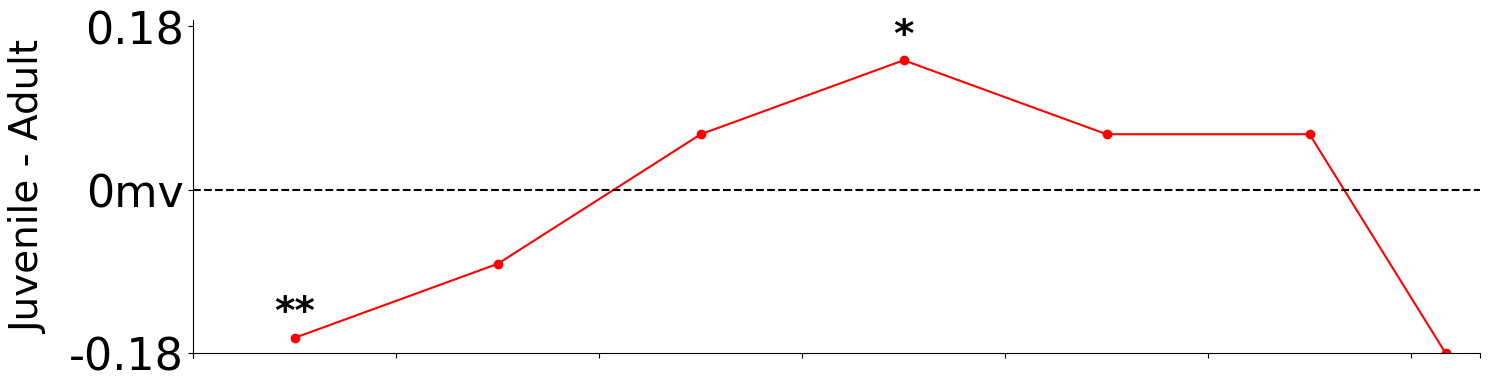

Index: 0 | Data name: male | Significance: ** | Y: 1 | O: 11 | P_value: 0.0077


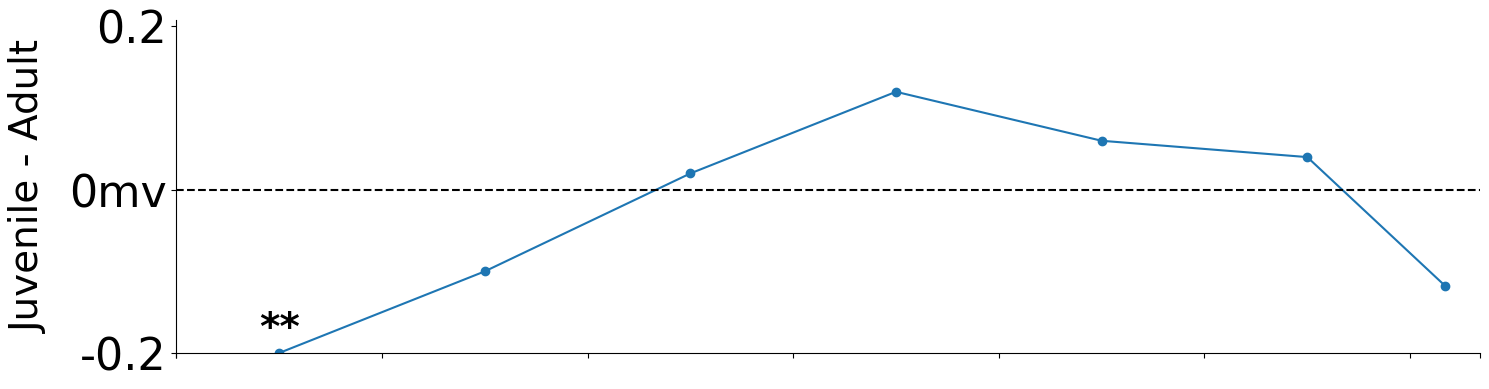

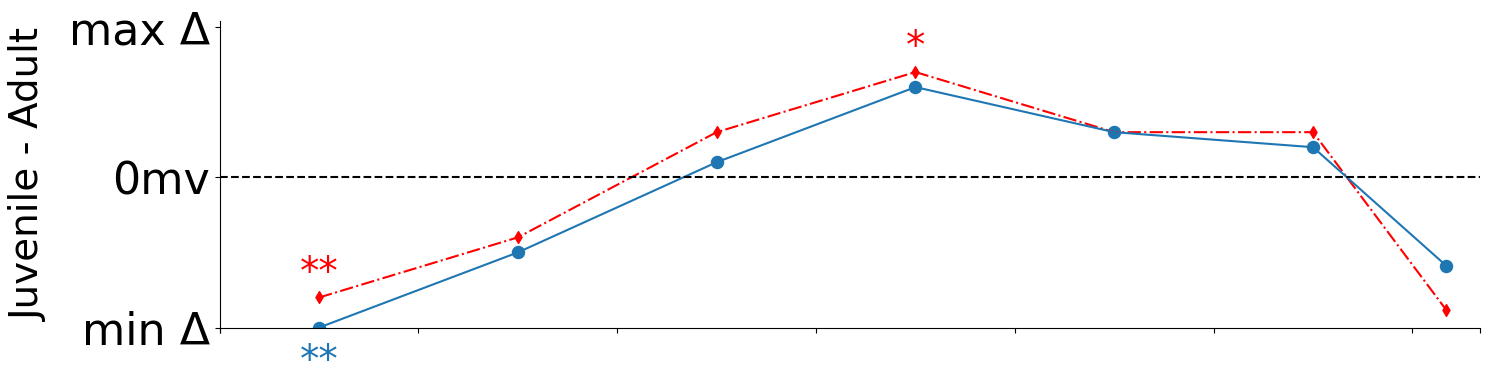

In [12]:
BuildGraph(data_f[data_f['Uniprot_ID'] == 'OSTP_RAT'], g='Average Young', age='fuzzy', s='female', scale=12, save=True)
BuildGraph(data_f[data_f['Uniprot_ID'] == 'OSTP_RAT'], g='Average Old', age='jumbo', s='female', scale=12, save=True)
BuildGraph(data_m[data_m['Uniprot_ID'] == 'OSTP_RAT'], g='Average Young', age='fuzzy', s='male', scale=13, save=True)
BuildGraph(data_m[data_m['Uniprot_ID'] == 'OSTP_RAT'], g='Average Old', age='jumbo', s='male', scale=13, save=True)

buildDiffGraph(data_f[data_f['Uniprot_ID'] == 'OSTP_RAT'], t='female', s='female', addRegion=[], save=True)
buildDiffGraph(data_m[data_m['Uniprot_ID'] == 'OSTP_RAT'], t='male', s='male', addRegion=[], save=True)

visualiseDiffComparisons([data_f[data_f['Uniprot_ID'] == 'OSTP_RAT'], data_m[data_m['Uniprot_ID'] == 'OSTP_RAT']], addRegion=[], save=True)
# visualiseDiffComparisons([data_f[data_f['Uniprot_ID'] == 'OSTP_RAT'], data_m[data_m['Uniprot_ID'] == 'OSTP_RAT']], addRegion=[('Signal pep-end', 16, 'center', 0.001), ('144-146 RGD_cas ', 144, 'right', -0.01), (' THRB cleavage (R152–S153)', 152, 'left', 0.001)])

C:\Users\jtudo\AppData\Local\Temp\ipykernel_15404\1529429153.py:113: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


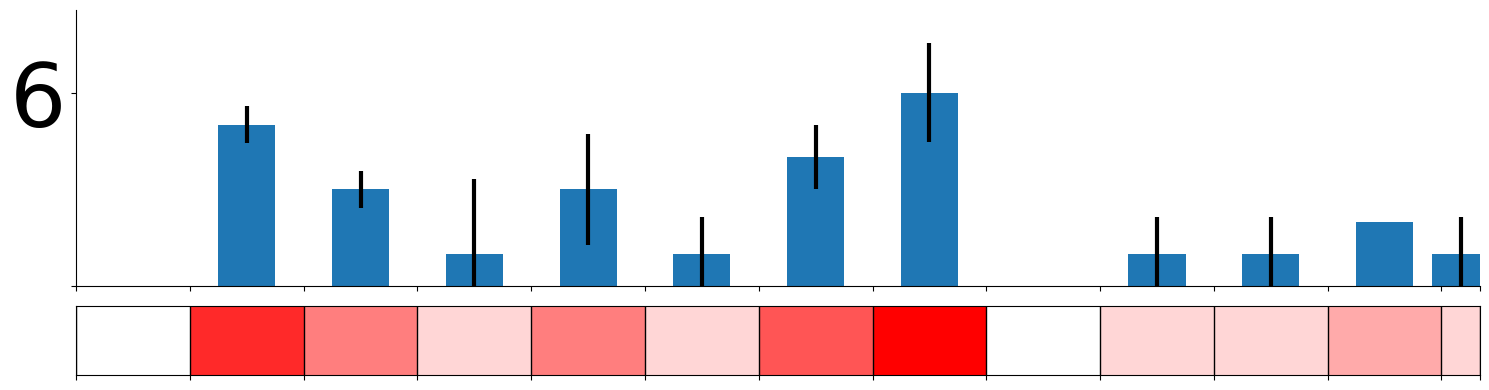

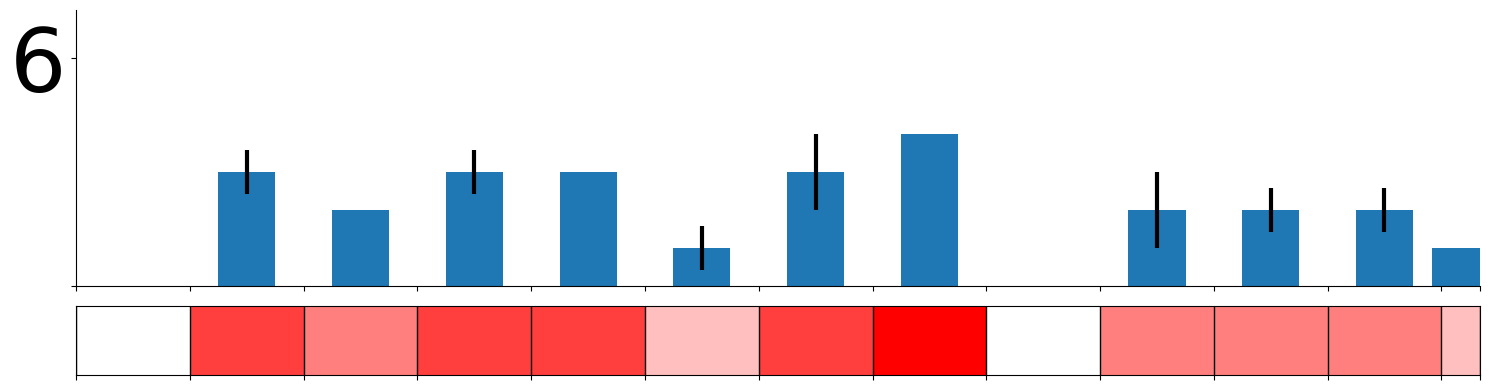

Index: 7 | Data name: female | Significance: * | Y: 6 | O: 4 | P_value: 0.0351


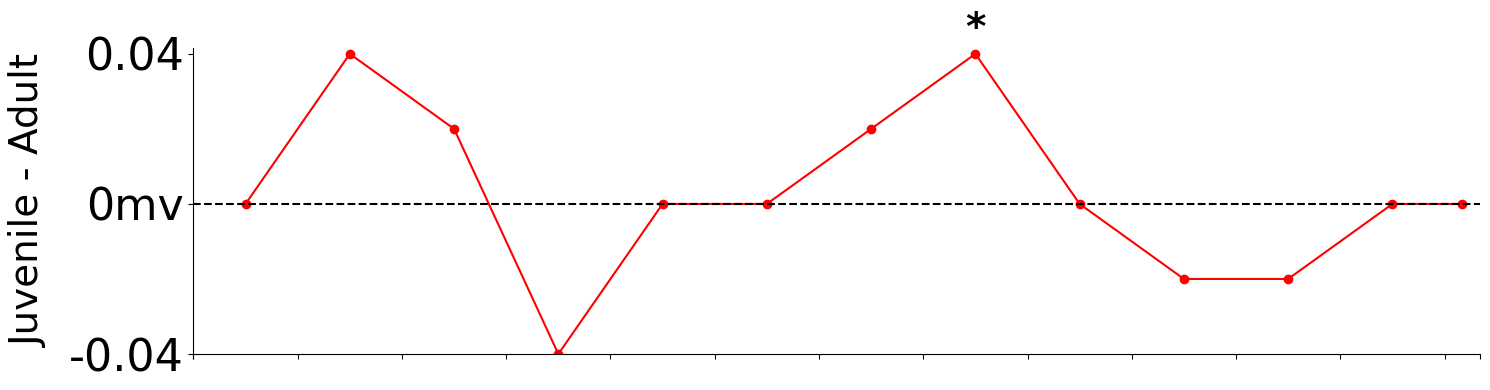

In [81]:
BuildGraph(data_f[data_f['Uniprot_ID'] == 'THRB_RAT'], g='Average Young', age='fuzzy', s='female', scale=6, save=True)
BuildGraph(data_f[data_f['Uniprot_ID'] == 'THRB_RAT'], g='Average Old', age='jumbo', s='female', scale=6, save=True)

buildDiffGraph(data_f[data_f['Uniprot_ID'] == 'THRB_RAT'], t='female', s='female', addRegion=[], save=True)
# buildDiffGraph(data_f[data_f['Uniprot_ID'] == 'THRB_RAT'], t='female', addRegion=[(' Xa cleavage site (359)', 359, 'left', -0.002), ('Interchain-start', 332, 'center', 0.001), ('Interchain-end', 478, 'center', 0.001)])

C:\Users\jtudo\AppData\Local\Temp\ipykernel_15404\1529429153.py:113: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


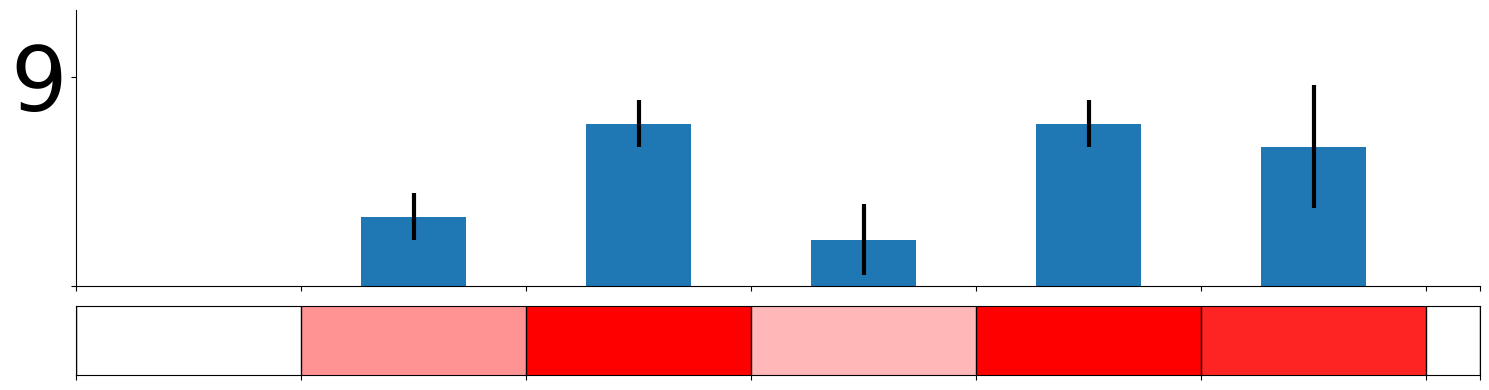

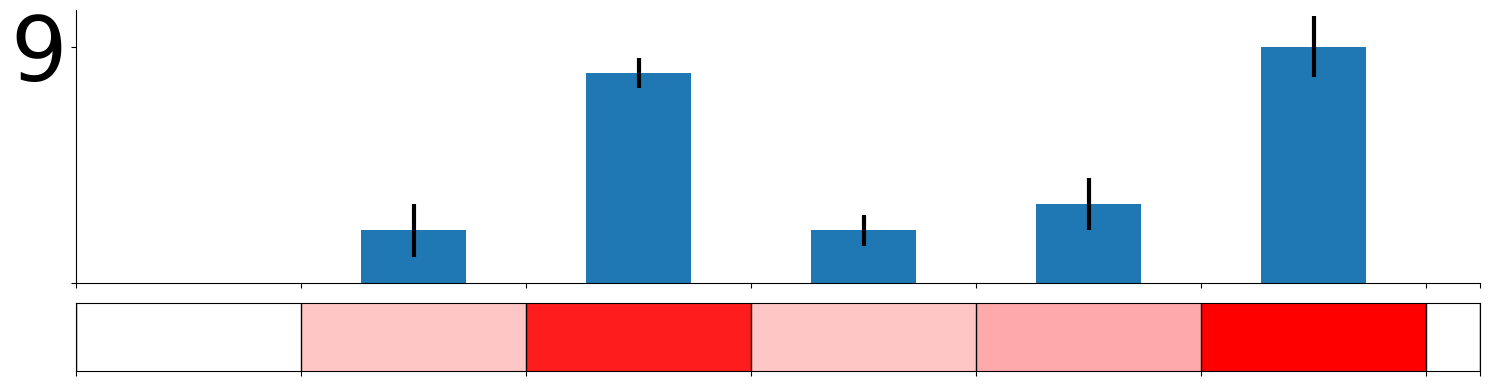

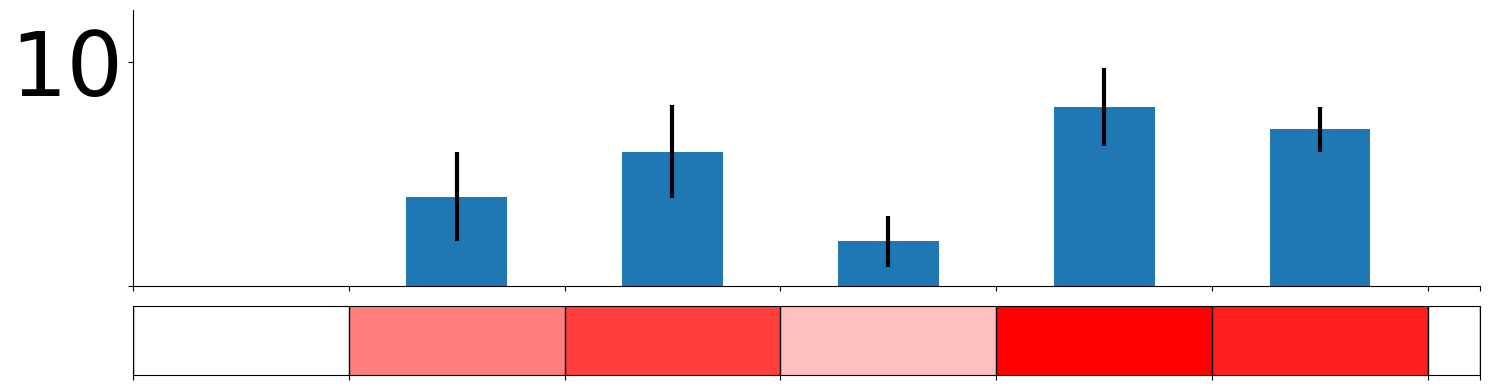

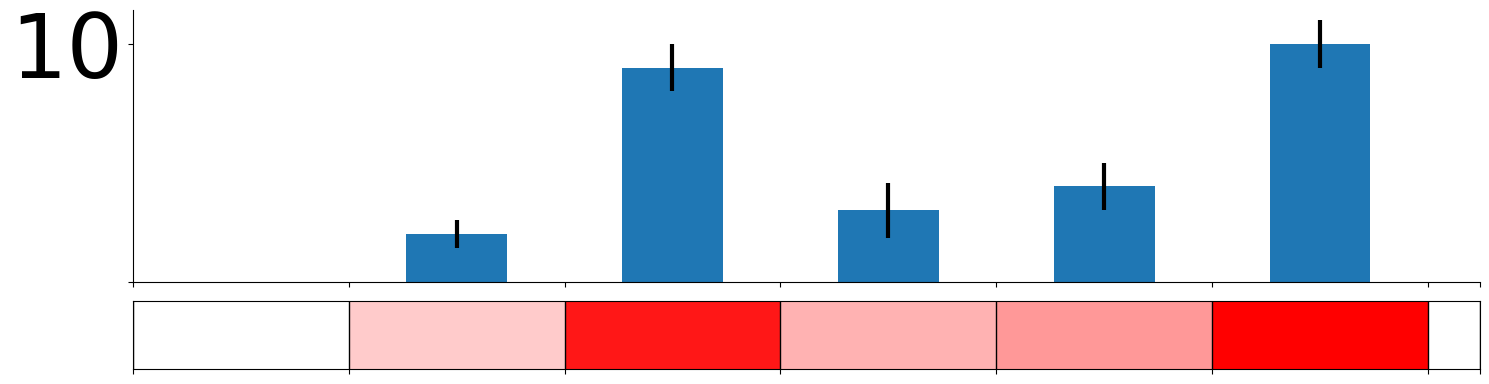

Index: 4 | Data name: female | Significance: *** | Y: 7 | O: 3 | P_value: 0.0007
Index: 5 | Data name: female | Significance: ** | Y: 6 | O: 9 | P_value: 0.0056


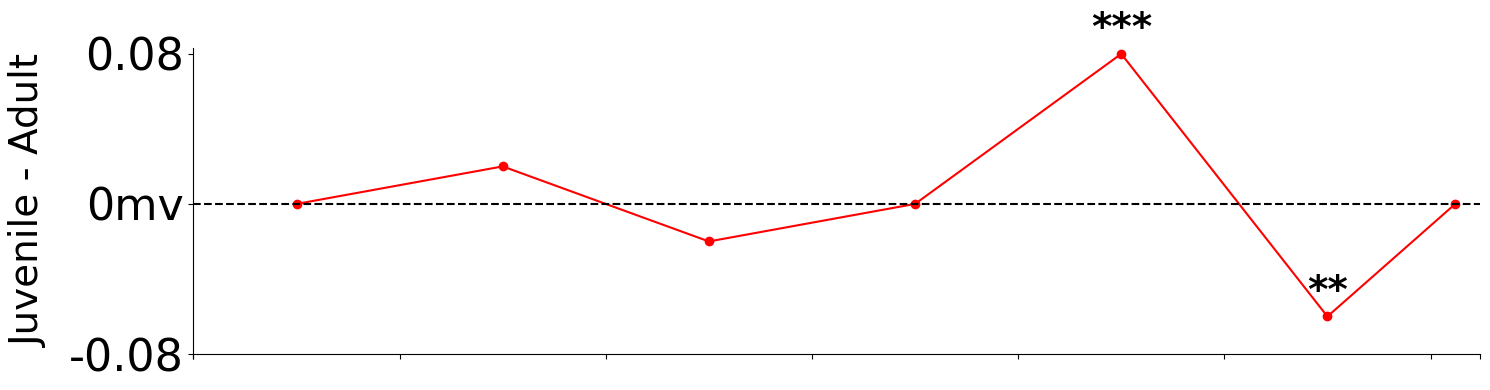

Index: 4 | Data name: male | Significance: ** | Y: 8 | O: 4 | P_value: 0.0014
Index: 5 | Data name: male | Significance: * | Y: 7 | O: 10 | P_value: 0.0231


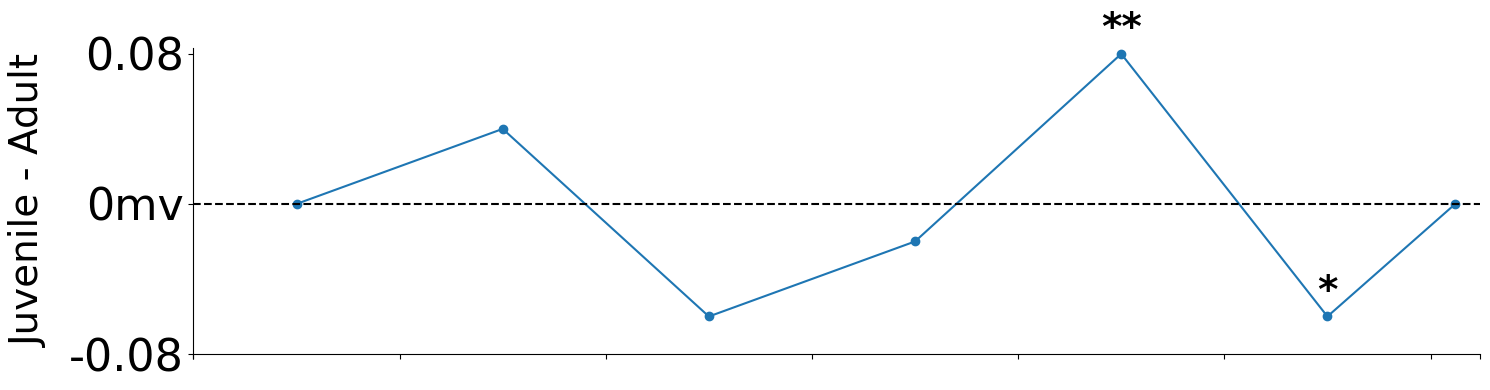

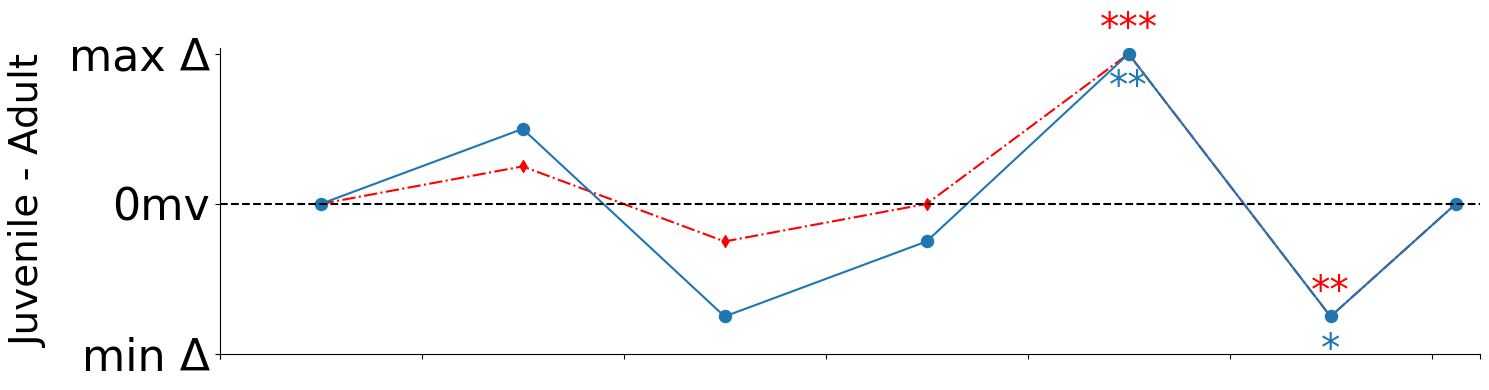

In [84]:
BuildGraph(data_f[data_f['Uniprot_ID'] == 'APOE_RAT'], g='Average Young', age='fuzzy', s='female', scale=9, save=True)
BuildGraph(data_f[data_f['Uniprot_ID'] == 'APOE_RAT'], g='Average Old', age='jumbo', s='female', scale=9, save=True)
BuildGraph(data_m[data_m['Uniprot_ID'] == 'APOE_RAT'], g='Average Young', age='fuzzy', s='male', scale=10, save=True)
BuildGraph(data_m[data_m['Uniprot_ID'] == 'APOE_RAT'], g='Average Old', age='jumbo', s='male', scale=10, save=True)

buildDiffGraph(data_f[data_f['Uniprot_ID'] == 'APOE_RAT'], t='female', s='female', addRegion=[], save=True)
buildDiffGraph(data_m[data_m['Uniprot_ID'] == 'APOE_RAT'], t='male', s='male', addRegion=[], save=True)

# visualiseDiffComparisons([data_f[data_f['Uniprot_ID'] == 'APOE_RAT'], data_m[data_m['Uniprot_ID'] == 'APOE_RAT']], addRegion=[('lipid binding/assoc-start', 202, 'center', 0.001), ('lipid binding/assoc-end', 282, 'center', 0.001), ('VLDL assoc-start ', 270, 'right', -0.005), (' VLDL assoc-end', 282, 'left', -0.005)])
visualiseDiffComparisons([data_f[data_f['Uniprot_ID'] == 'APOE_RAT'], data_m[data_m['Uniprot_ID'] == 'APOE_RAT']], addRegion=[], save=True)

C:\Users\jtudo\AppData\Local\Temp\ipykernel_40828\3155399219.py:113: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


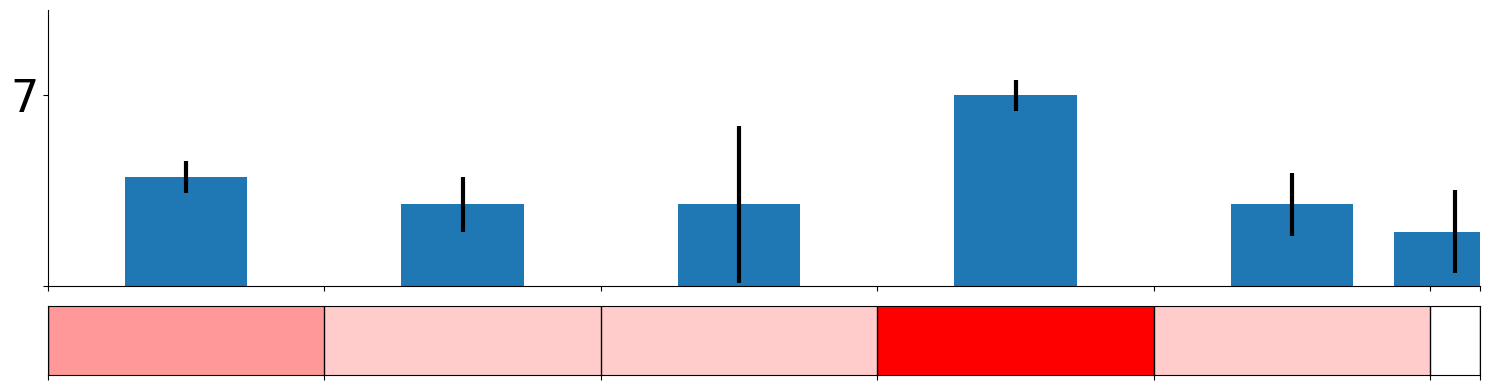

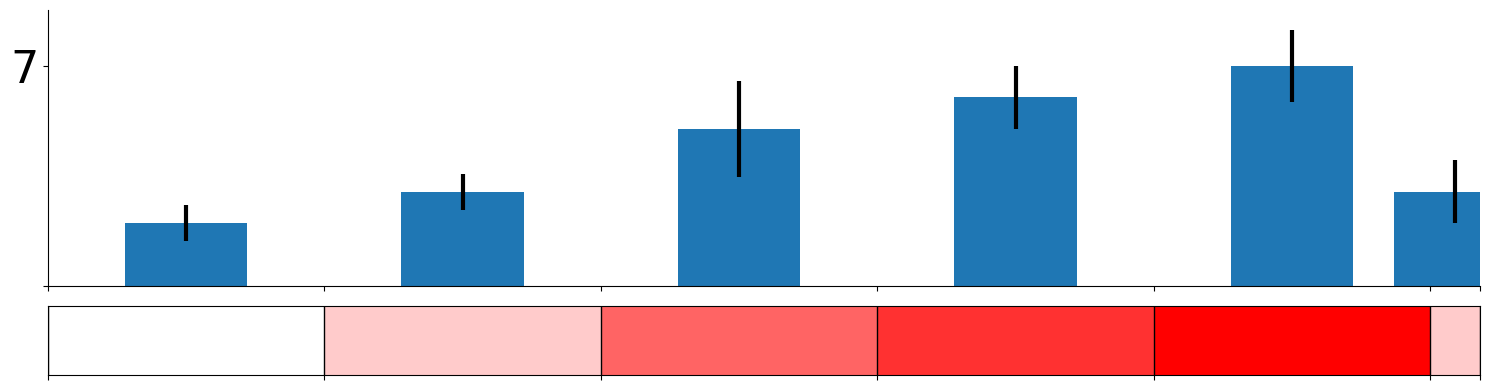

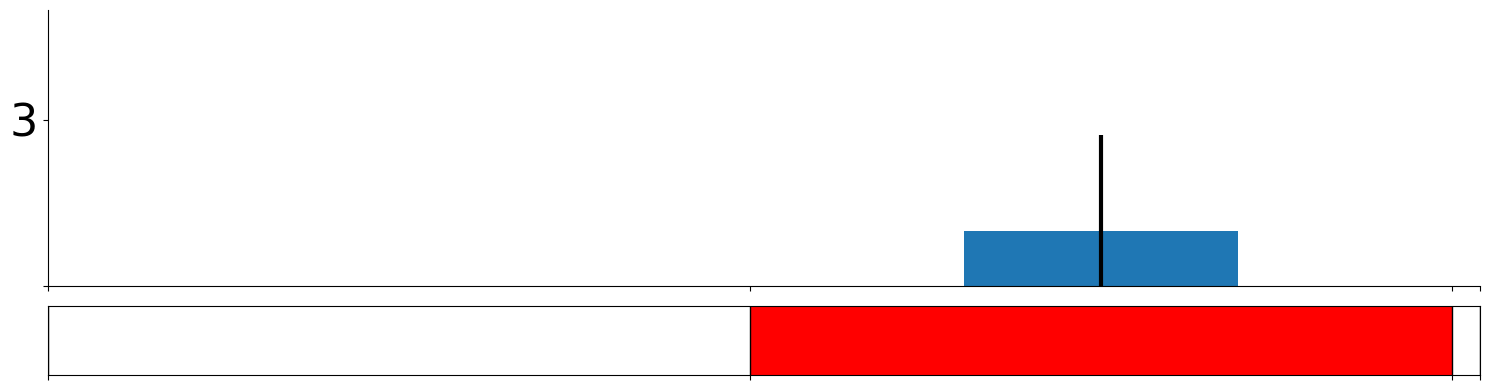

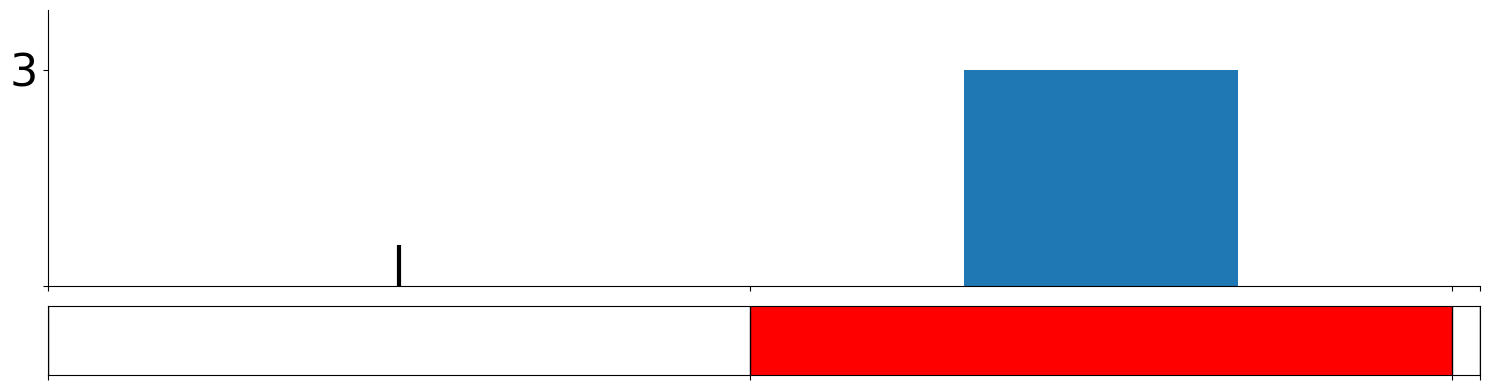

In [40]:
BuildGraph(data_f[data_f['Uniprot_ID'] == 'APOA1_RAT'], g='Average Young', age='fuzzy', s='female', scale=7, save=True)
BuildGraph(data_f[data_f['Uniprot_ID'] == 'APOA1_RAT'], g='Average Old', age='jumbo', s='female',  scale=7, save=True)
BuildGraph(data_f[data_f['Uniprot_ID'] == 'APOA2_RAT'], g='Average Young', age='fuzzy', s='female', scale=3, save=True)
BuildGraph(data_f[data_f['Uniprot_ID'] == 'APOA2_RAT'], g='Average Old', age='jumbo', s='female', scale=3, save=True)

# buildDiffGraph(data_f[data_f['Uniprot_ID'] == 'APOA1_RAT'], t='female', s='female', addRegion=[], save=True)
# buildDiffGraph(data_f[data_f['Uniprot_ID'] == 'APOA2_RAT'], t='female', s='female', addRegion=[], save=True)

C:\Users\jtudo\AppData\Local\Temp\ipykernel_40828\3155399219.py:113: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


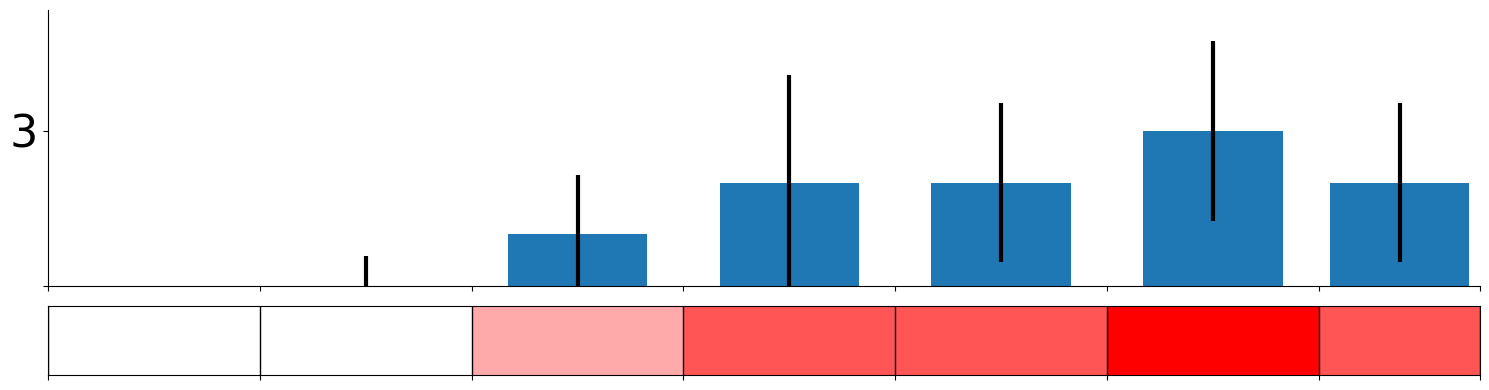

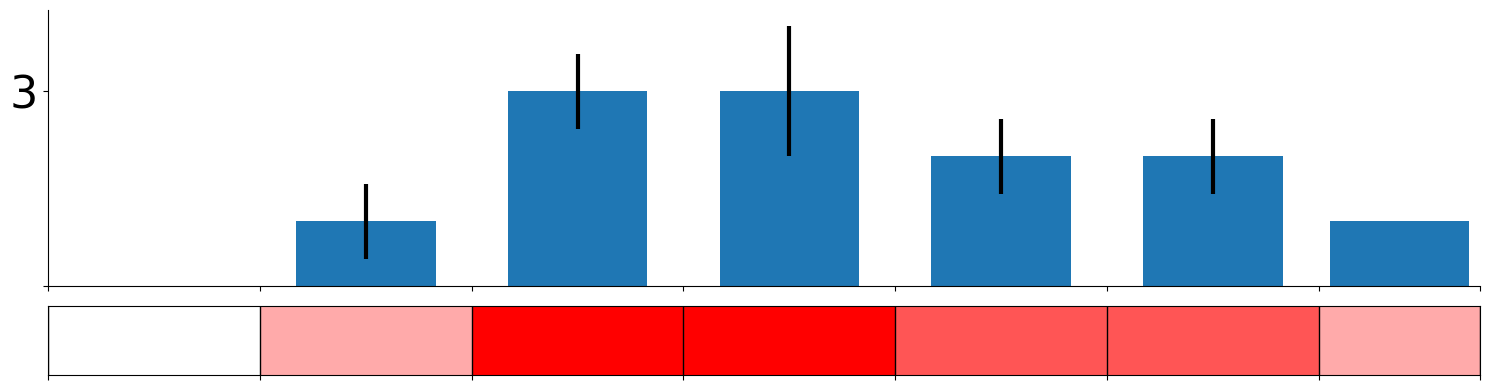

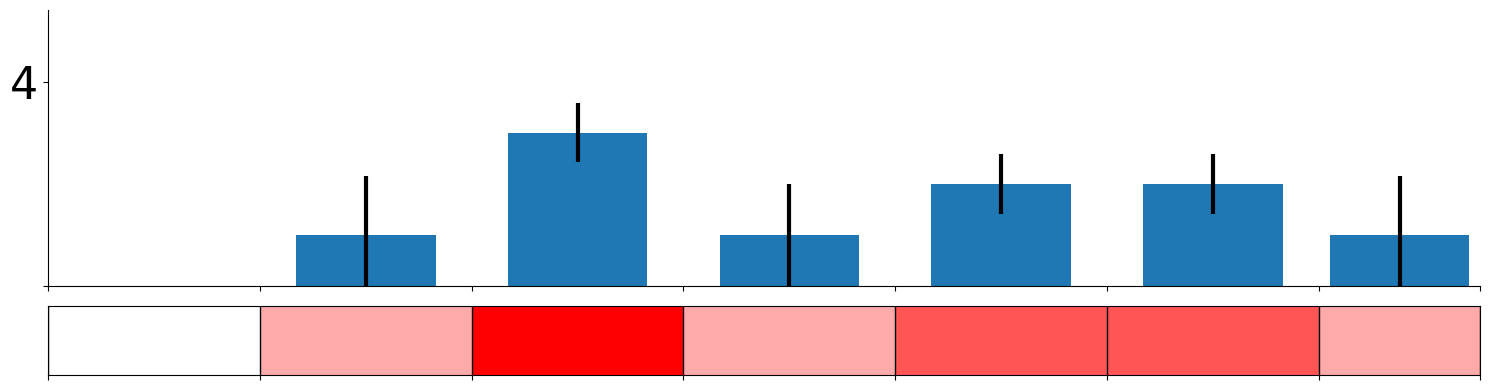

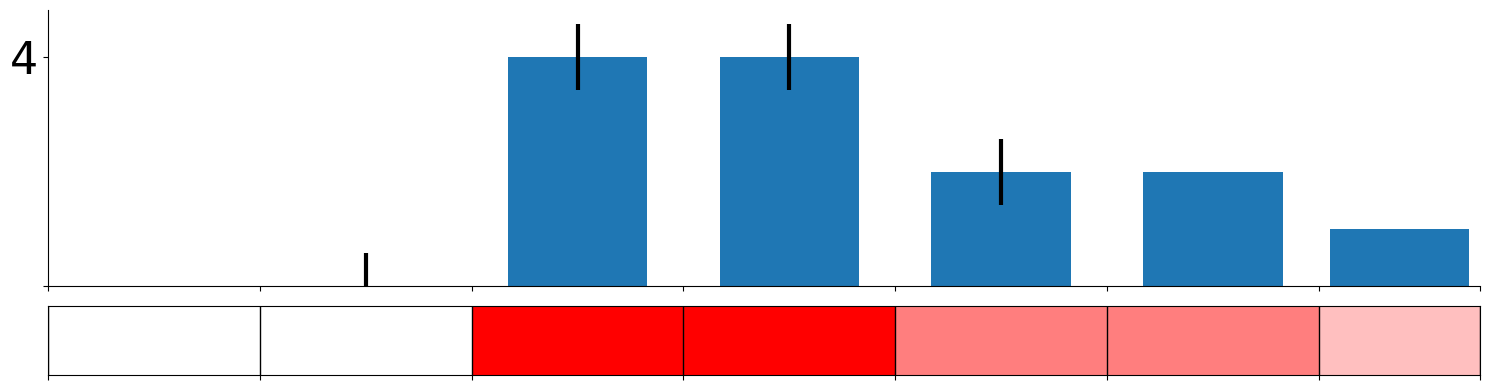

In [41]:
BuildGraph(data_f[data_f['Uniprot_ID'] == 'LUM_RAT'], g='Average Young', age='fuzzy', s='female', scale=3, save=True)
BuildGraph(data_f[data_f['Uniprot_ID'] == 'LUM_RAT'], g='Average Old', age='jumbo', s='female', scale=3, save=True)
BuildGraph(data_m[data_m['Uniprot_ID'] == 'LUM_RAT'], g='Average Young', age='fuzzy', s='male', scale=4, save=True)
BuildGraph(data_m[data_m['Uniprot_ID'] == 'LUM_RAT'], g='Average Old', age='jumbo', s='male', scale=4, save=True)

# buildDiffGraph(data_f[data_f['Uniprot_ID'] == 'LUM_RAT'], t='female', s='female', addRegion=[], save=True)
# buildDiffGraph(data_m[data_m['Uniprot_ID'] == 'LUM_RAT'], t='male', s='male', addRegion=[], save=True)

# visualiseDiffComparisons([data_f[data_f['Uniprot_ID'] == 'LUM_RAT'], data_m[data_m['Uniprot_ID'] == 'LUM_RAT']], addRegion=[('Signal pep-end', 18, 'center', 0.001)])
# visualiseDiffComparisons([data_f[data_f['Uniprot_ID'] == 'LUM_RAT'], data_m[data_m['Uniprot_ID'] == 'LUM_RAT']], addRegion=[], save=True)

C:\Users\jtudo\AppData\Local\Temp\ipykernel_40828\3155399219.py:113: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


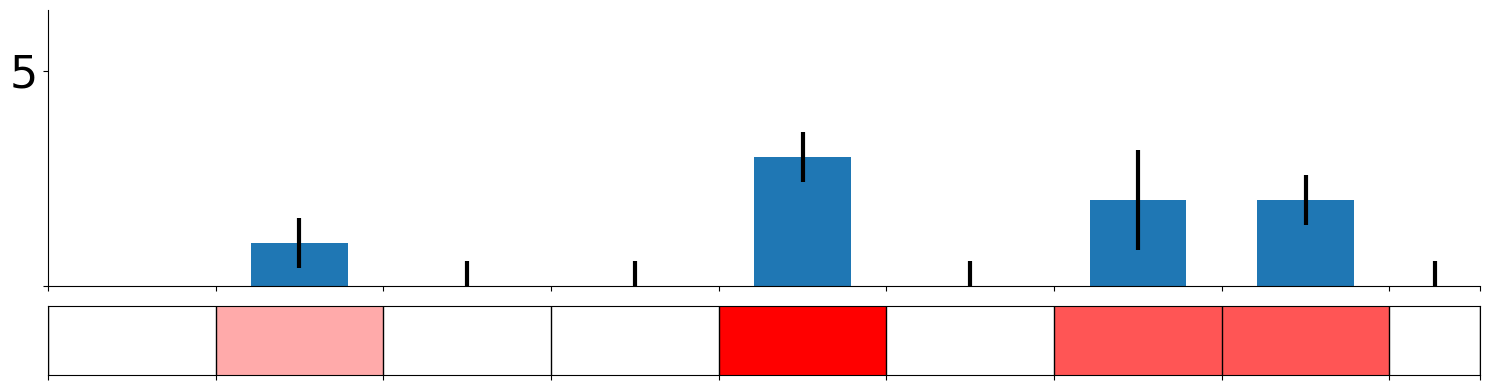

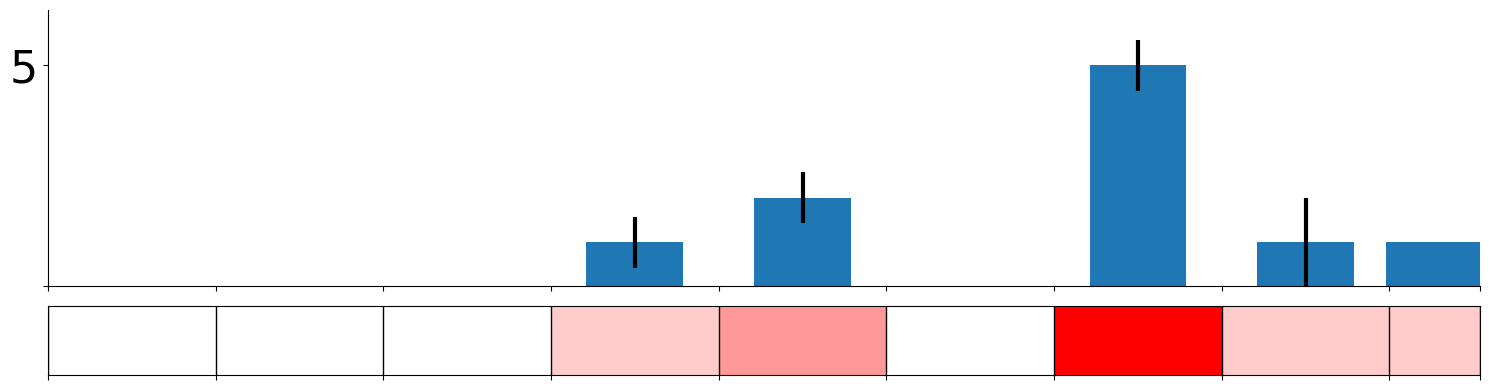

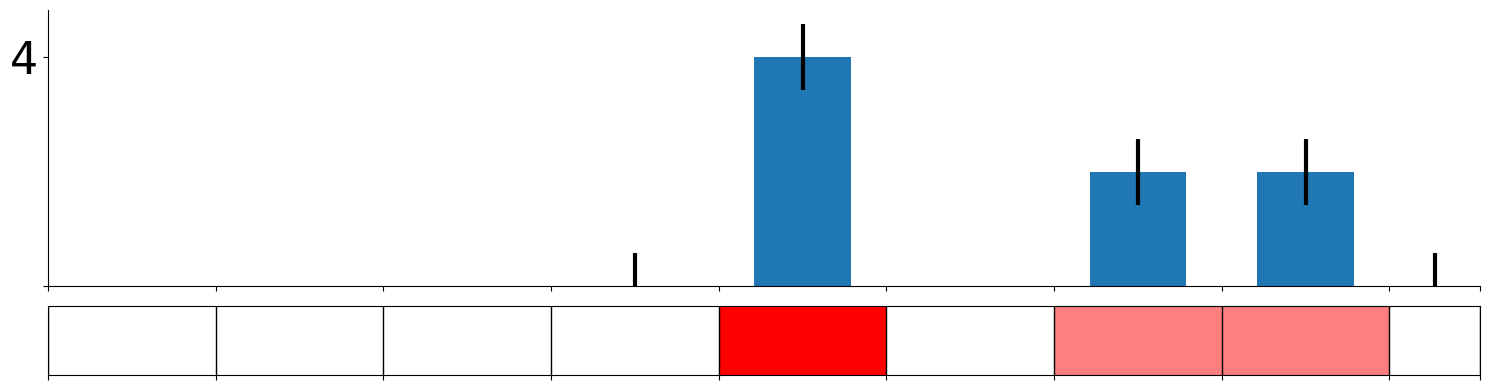

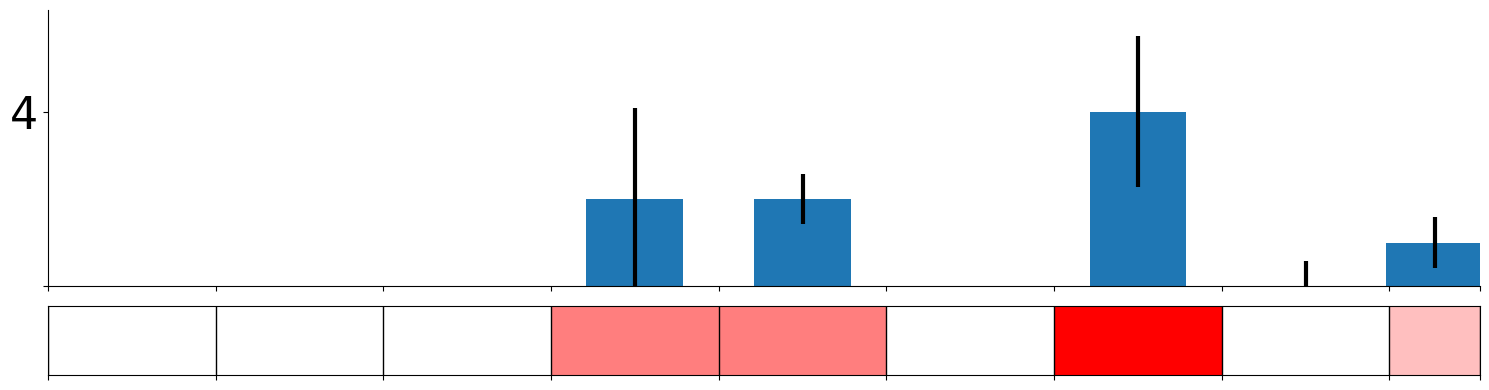

In [42]:
BuildGraph(data_f[data_f['Uniprot_ID'] == 'MFGM_RAT'], g='Average Young', age='fuzzy', s='female', scale=5, save=True)
BuildGraph(data_f[data_f['Uniprot_ID'] == 'MFGM_RAT'], g='Average Old', age='jumbo', s='female', scale=5, save=True)
BuildGraph(data_m[data_m['Uniprot_ID'] == 'MFGM_RAT'], g='Average Young', age='fuzzy', s='male', scale=4, save=True)
BuildGraph(data_m[data_m['Uniprot_ID'] == 'MFGM_RAT'], g='Average Old', age='jumbo', s='male', scale=4, save=True)

# buildDiffGraph(data_f[data_f['Uniprot_ID'] == 'MFGM_RAT'], t='female', s='female', addRegion=[], save=True)
# buildDiffGraph(data_m[data_m['Uniprot_ID'] == 'MFGM_RAT'], t='male', s='male', addRegion=[], save=True)

# visualiseDiffComparisons([data_f[data_f['Uniprot_ID'] == 'MFGM_RAT'], data_m[data_m['Uniprot_ID'] == 'MFGM_RAT']], addRegion=[('F5/8 type C-start', 111, 'center', 0.001), ('F5/8 type C-end', 267, 'center', 0.001), ('F5/8 type C 2-start', 272, 'center', -0.003), ('F5/8 type C 2-end', 427, 'center', -0.003)])
# visualiseDiffComparisons([data_f[data_f['Uniprot_ID'] == 'MFGM_RAT'], data_m[data_m['Uniprot_ID'] == 'MFGM_RAT']], addRegion=[], save=True)

C:\Users\jtudo\AppData\Local\Temp\ipykernel_40828\3155399219.py:113: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


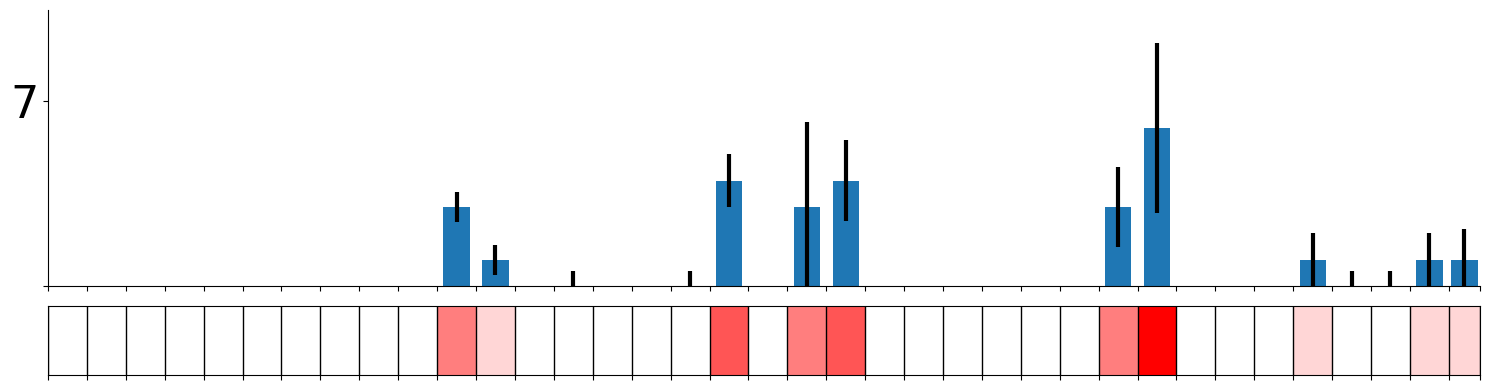

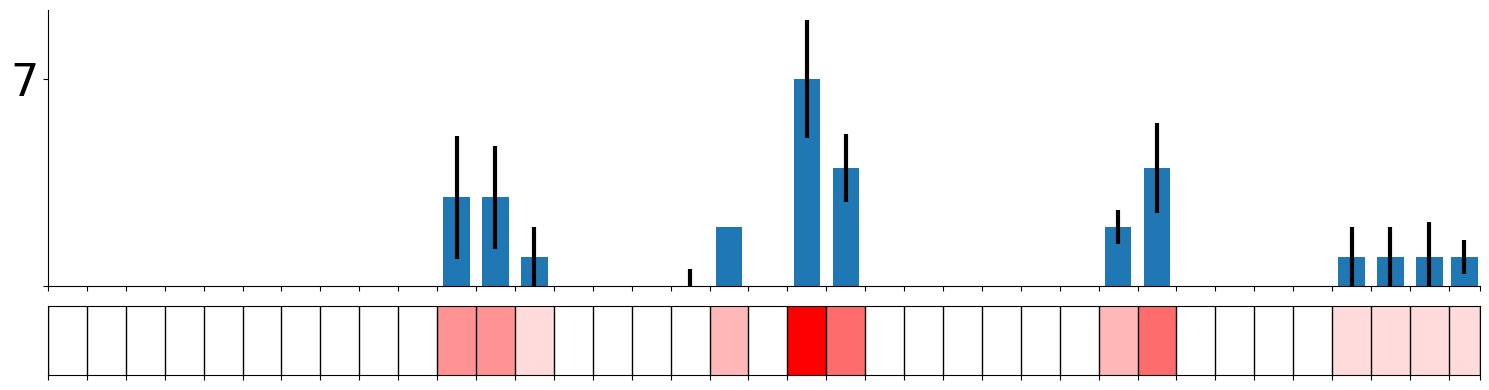

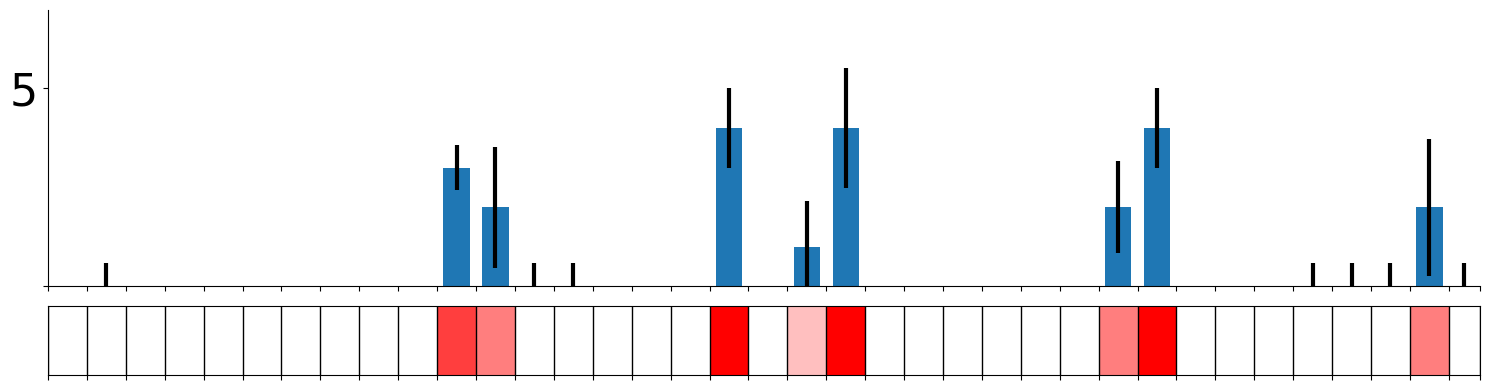

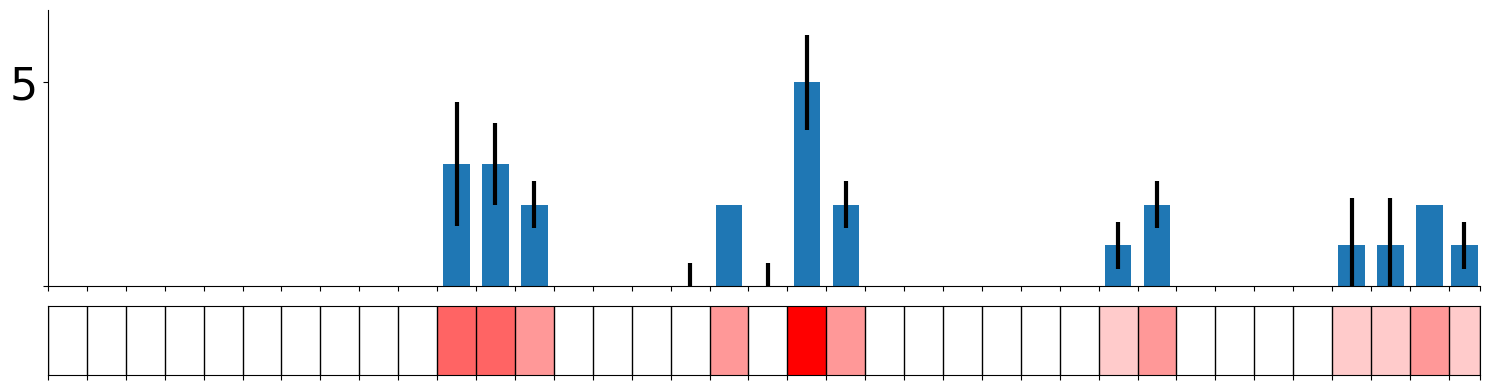

In [44]:
BuildGraph(data_f[data_f['Uniprot_ID'] == 'CO5A1_RAT'], g='Average Young', age='fuzzy', s='female', scale=7, save=True)
BuildGraph(data_f[data_f['Uniprot_ID'] == 'CO5A1_RAT'], g='Average Old', age='jumbo', s='female', scale=7, save=True)
BuildGraph(data_m[data_m['Uniprot_ID'] == 'CO5A1_RAT'], g='Average Young', age='fuzzy', s='male', scale=5, save=True)
BuildGraph(data_m[data_m['Uniprot_ID'] == 'CO5A1_RAT'], g='Average Old', age='jumbo', s='male', scale=5, save=True)

# buildDiffGraph(data_f[data_f['Uniprot_ID'] == 'CO5A1_RAT'], t='female', s='female', addRegion=[], save=True)
# buildDiffGraph(data_m[data_m['Uniprot_ID'] == 'CO5A1_RAT'], t='male', s='male', addRegion=[], save=True)

# visualiseDiffComparisons([data_f[data_f['Uniprot_ID'] == 'CO5A1_RAT'], data_m[data_m['Uniprot_ID'] == 'CO5A1_RAT']], addRegion=[('PR', 948, 'right', 0.001, ''), ('', 975, 'left', 0.001), ('non-helical-start', 1573, 'left', -0.008), ('PR', 1383, 'right', -0.004),('', 1398, 'left', -0.004),('PR', 1456, 'right', 0.001),('', 1470, 'left', 0.001)])
# visualiseDiffComparisons([data_f[data_f['Uniprot_ID'] == 'CO5A1_RAT'], data_m[data_m['Uniprot_ID'] == 'CO5A1_RAT']], addRegion=[], save=True)

In [26]:
# BuildGraph(data_m[data_m['Uniprot_ID'] == 'COBA1_RAT'], g='Average Young', age='fuzzy', s='male')
# BuildGraph(data_m[data_m['Uniprot_ID'] == 'COBA1_RAT'], g='Average Old', age='jumbo', s='male')

# buildDiffGraph(data_m[data_m['Uniprot_ID'] == 'COBA1_RAT'], t='male', s='male', addRegion=[], save=True)

# buildDiffGraph(data_m[data_m['Uniprot_ID'] == 'COBA1_RAT'], t='male', addRegion=[('CO11A1-chain start', 512, 'center', 0.001), ('C-term-prop-start', 1562, 'center', 0.001)])

C:\Users\jtudo\AppData\Local\Temp\ipykernel_15404\1529429153.py:113: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


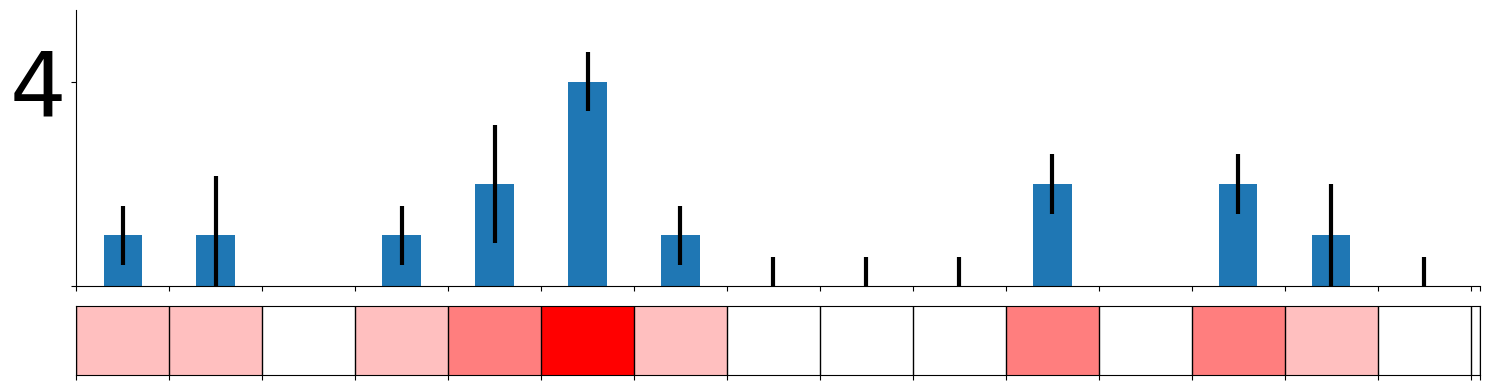

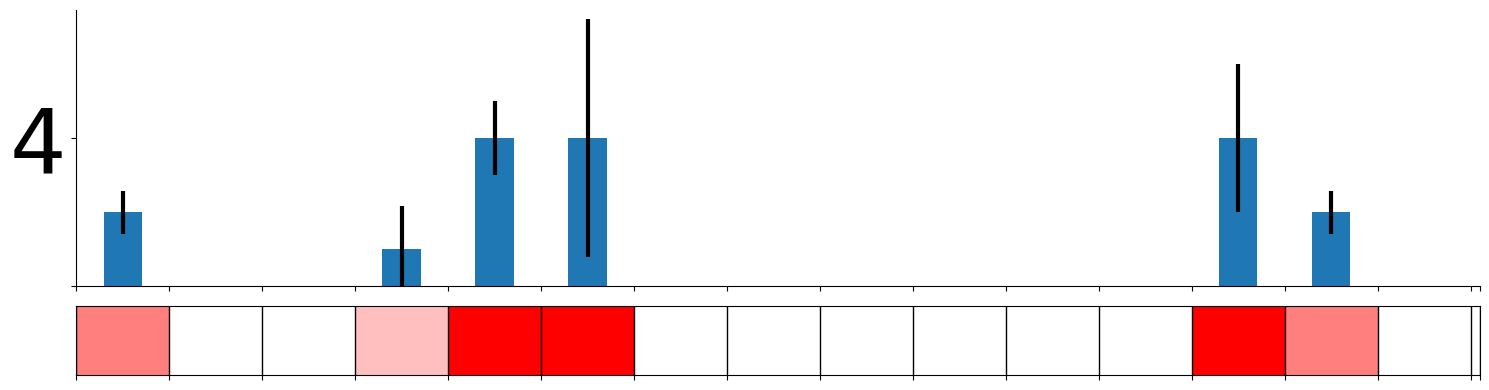

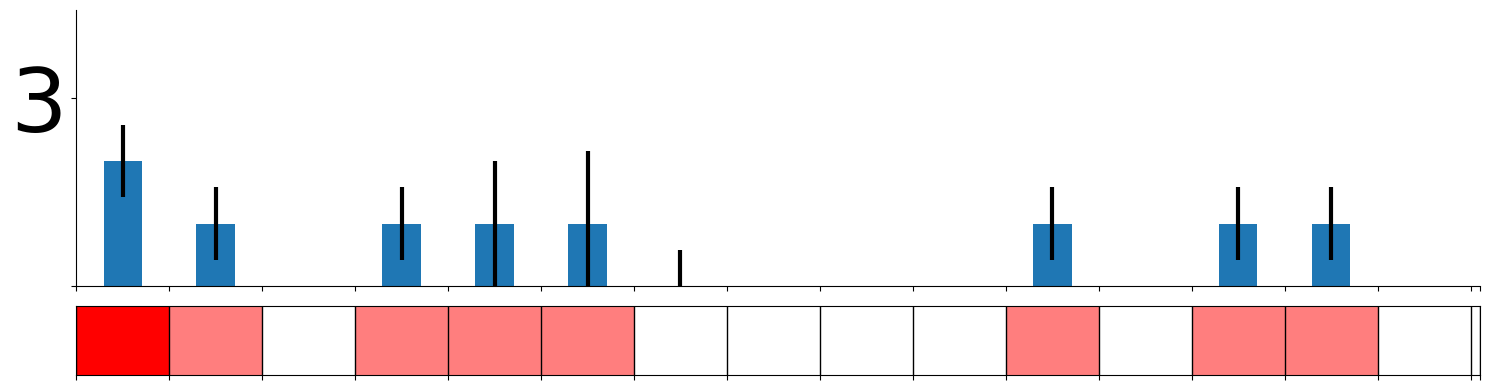

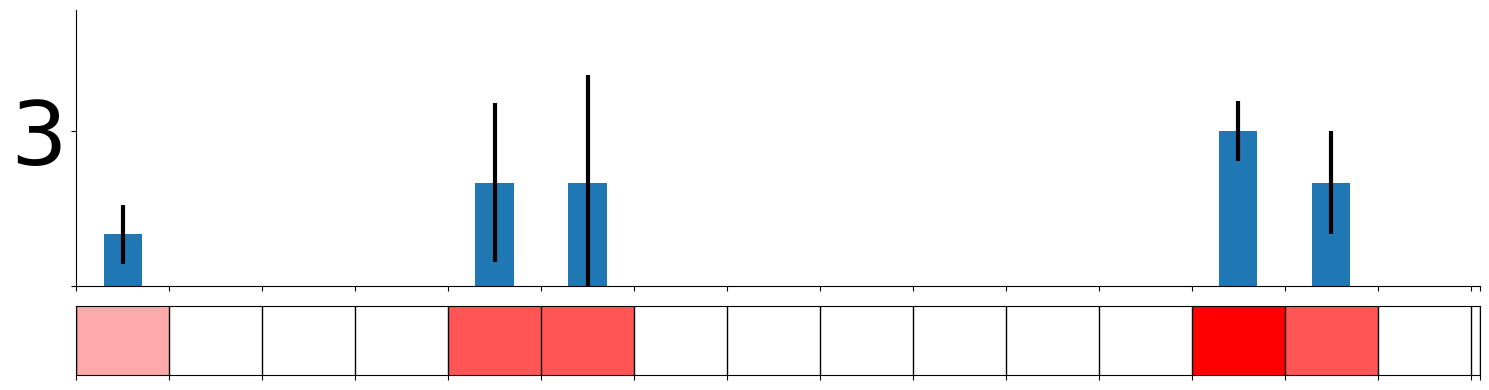

Index: 12 | Data name: female | Significance: * | Y: 2 | O: 4 | P_value: 0.0272


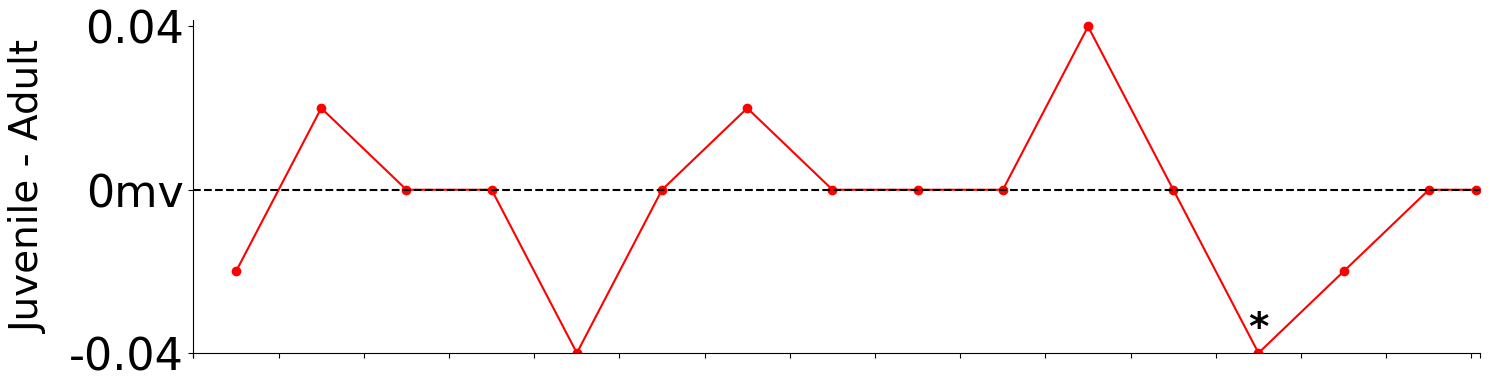

Index: 12 | Data name: male | Significance: ** | Y: 1 | O: 3 | P_value: 0.0048


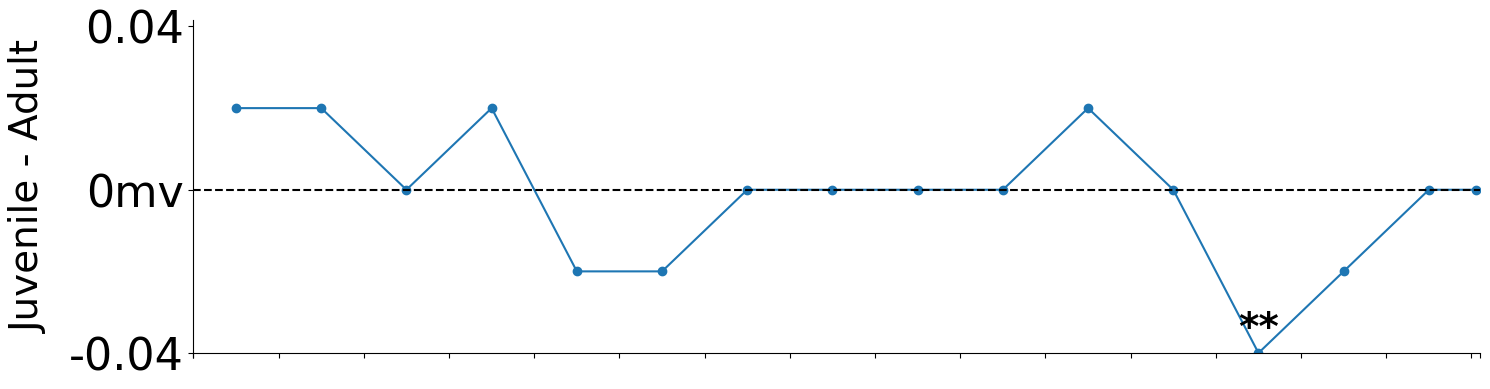

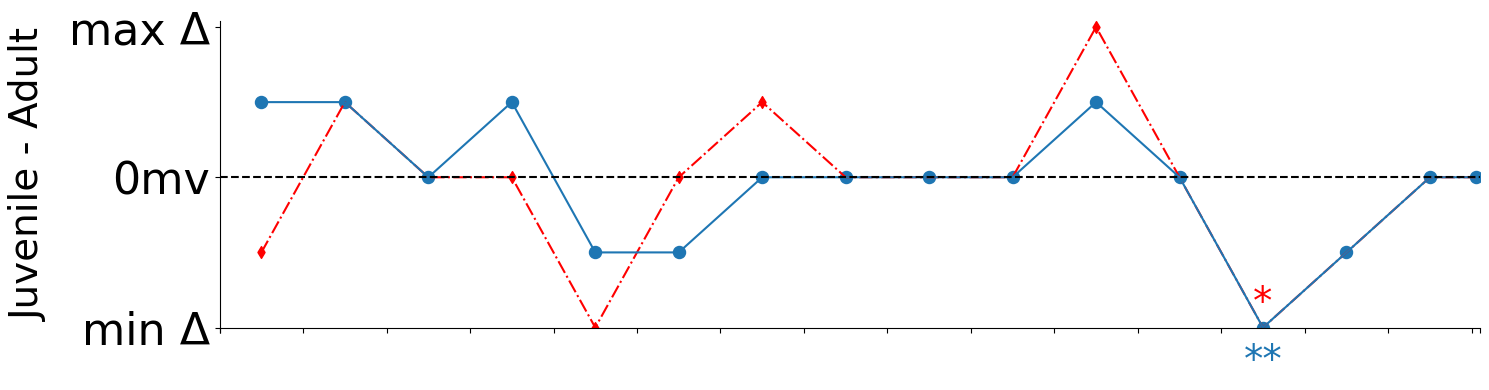

In [82]:
BuildGraph(data_f[data_f['Uniprot_ID'] == 'COMP_RAT'], g='Average Young', age='fuzzy', s='female', scale=4, save=True)
BuildGraph(data_f[data_f['Uniprot_ID'] == 'COMP_RAT'], g='Average Old', age='jumbo', s='female', scale=4, save=True)
BuildGraph(data_m[data_m['Uniprot_ID'] == 'COMP_RAT'], g='Average Young', age='fuzzy', s='male', scale=3, save=True)
BuildGraph(data_m[data_m['Uniprot_ID'] == 'COMP_RAT'], g='Average Old', age='jumbo', s='male', scale=3, save=True)

buildDiffGraph(data_f[data_f['Uniprot_ID'] == 'COMP_RAT'], t='female', s='female', addRegion=[], save=True)
buildDiffGraph(data_m[data_m['Uniprot_ID'] == 'COMP_RAT'], t='male', s='male', addRegion=[], save=True)

visualiseDiffComparisons([data_f[data_f['Uniprot_ID'] == 'COMP_RAT'], data_m[data_m['Uniprot_ID'] == 'COMP_RAT']], addRegion=[], save=True)
# visualiseDiffComparisons([data_f[data_f['Uniprot_ID'] == 'COMP_RAT'], data_m[data_m['Uniprot_ID'] == 'COMP_RAT']], addRegion=[('Mediates cell survival', 525, 'left', 0.001), ('',755, 'center', 0.001)])

C:\Users\jtudo\AppData\Local\Temp\ipykernel_40828\3155399219.py:113: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


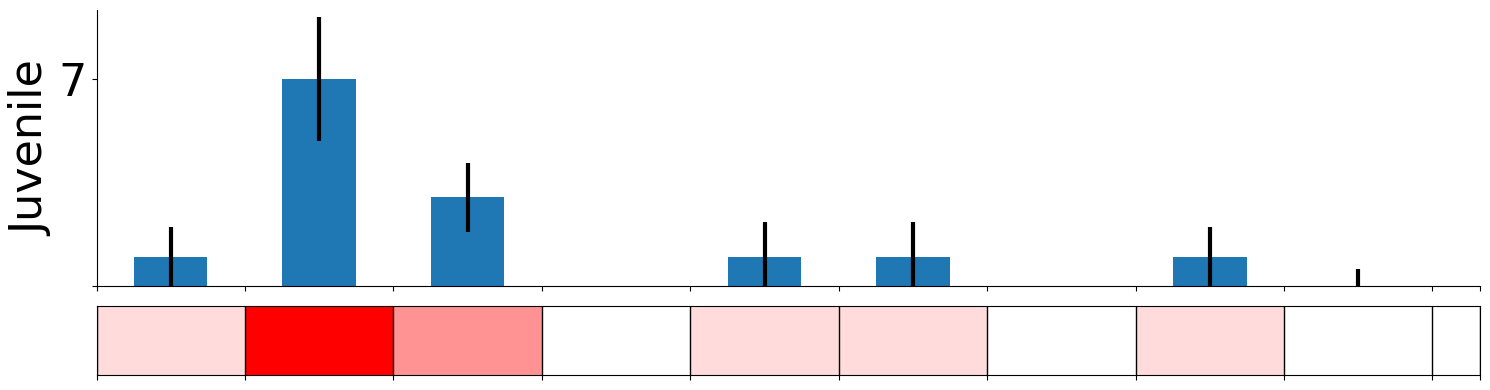

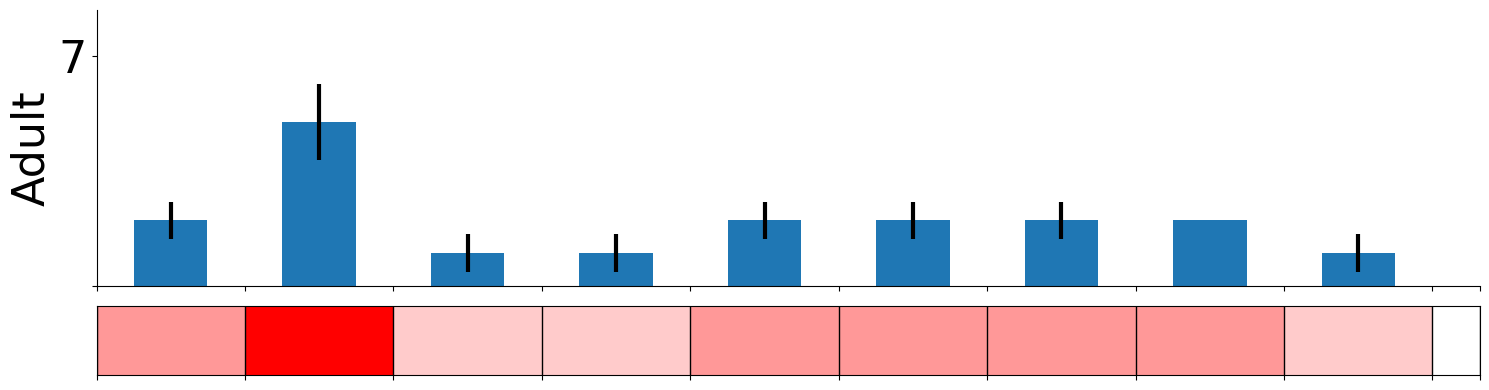

In [46]:
BuildGraph(data_f[data_f['Uniprot_ID'] == 'MMP13_RAT'], g='Average Young', age='fuzzy', s='female', t='Juvenile',  scale=7, save=True)
BuildGraph(data_f[data_f['Uniprot_ID'] == 'MMP13_RAT'], g='Average Old', age='jumbo', s='female', t='Adult',  scale=7, save=True)

# buildDiffGraph(data_f[data_f['Uniprot_ID'] == 'MMP13_RAT'], t='female', s='female', addRegion=[], save=True)

In [15]:
data_f[data_f['Uniprot_ID'] == 'SERPH_RAT']

,Uniprot_ID,Domain_Name,Domain_Start,Domain_Finish,p: Aged vs Young,Domain Type,Domain_Length,FZ1_F (ms-status_RAT1),FZ2_F (ms-status_RAT2),FZ3_F (ms-status_RAT3),JA2_F (ms-status_RAT8),JA5_F (ms-status_RAT11),JA6_F (ms-status_RAT12),Diff Young vs old (average young - old / 50),Average Young,Average Old,Peptides contributing to Young,Peptides contributing to Old,Original_FZ1_F (ms-status_RAT1),Original_FZ2_F (ms-status_RAT2),Original_FZ3_F (ms-status_RAT3),Original_JA2_F (ms-status_RAT8),Original_JA5_F (ms-status_RAT11),Original_JA6_F (ms-status_RAT12),GeneAC,Uniprot_ACs,SD_g1,SD_g2
645,SERPH_RAT,50Step_Domain_p0_to_50,0,50,1.0000,50.0 AA STEP,50,0,1,0,1,0,0,0.000000,0,0,NaN,NaN,0,1,0,1,0,0,SERPH_RAT,P29457;\r,0.577350,0.577350
646,SERPH_RAT,50Step_Domain_p50.0_to_100.0,50,100,0.0765,50.0 AA STEP,50,0,1,0,2,1,3,-0.040000,0,2,NaN,DQAVENILLSPLVVASSLGLVSLGGK,0,1,0,3,1,2,SERPH_RAT,P29457;\r,0.577350,1.000000
647,SERPH_RAT,50Step_Domain_p100.0_to_150.0,100,150,1.0000,50.0 AA STEP,50,3,0,1,1,1,1,0.000000,1,1,LYGPSSVSFADDFVR,LYGPSSVSFADDFVR,1,0,1,1,1,1,SERPH_RAT,P29457;\r,1.527525,0.000000
648,SERPH_RAT,50Step_Domain_p150.0_to_200.0,150,200,1.0000,50.0 AA STEP,50,0,0,0,0,0,0,0.000000,0,0,NaN,NaN,0,0,0,0,0,0,SERPH_RAT,P29457;\r,0.000000,0.000000
649,SERPH_RAT,50Step_Domain_p200.0_to_250.0,200,250,1.0000,50.0 AA STEP,50,0,0,0,0,0,0,0.000000,0,0,NaN,NaN,0,0,0,0,0,0,SERPH_RAT,P29457;\r,0.000000,0.000000
650,SERPH_RAT,50Step_Domain_p250.0_to_300.0,250,300,1.0000,50.0 AA STEP,50,0,2,1,1,1,0,0.000000,1,1,LQLVEMPLAHK,NaN,0,2,1,2,1,0,SERPH_RAT,P29457;\r,1.000000,0.577350
651,SERPH_RAT,50Step_Domain_p300.0_to_350.0,300,350,1.0000,50.0 AA STEP,50,0,1,0,2,0,0,-0.020000,0,1,NaN,NaN,0,1,0,4,0,0,SERPH_RAT,P29457;\r,0.577350,1.154701
652,SERPH_RAT,50Step_Domain_p350.0_to_400.0,350,400,0.0171,50.0 AA STEP,50,3,2,3,0,1,1,0.040000,3,1,DNQSGSLLFIGR LFYADHPFIFLVR,DNQSGSLLFIGR,1,2,2,0,1,1,SERPH_RAT,P29457;\r,0.577350,0.577350
653,SERPH_RAT,50Step_Domain_p400.0_to_417.0,400,417,0.9297,50.0 AA STEP,17,3,1,1,0,1,1,0.058824,2,1,DNQSGSLLFIGR,DNQSGSLLFIGR,1,1,1,0,1,1,SERPH_RAT,P29457;\r,1.154701,0.577350


C:\Users\jtudo\AppData\Local\Temp\ipykernel_24988\1529429153.py:113: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


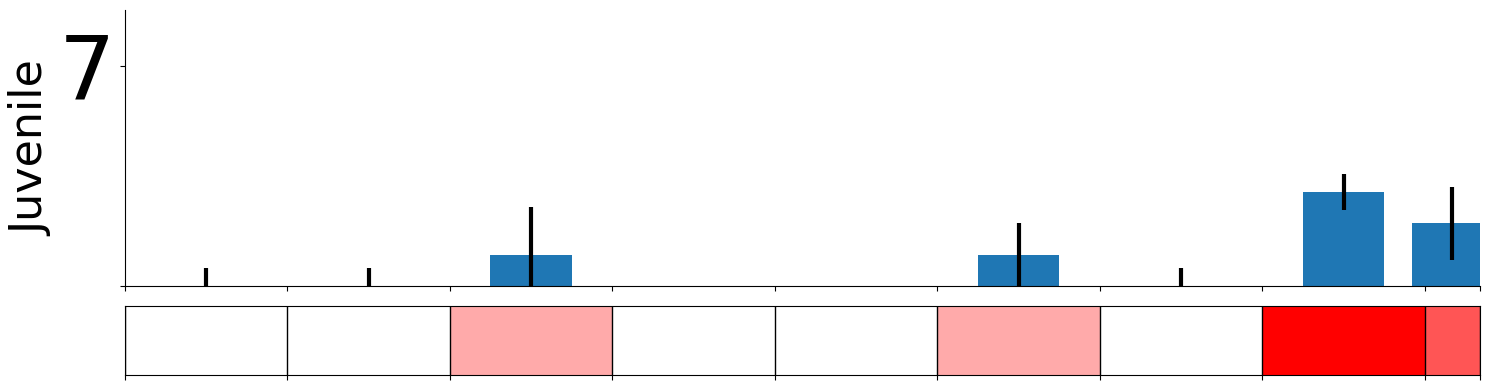

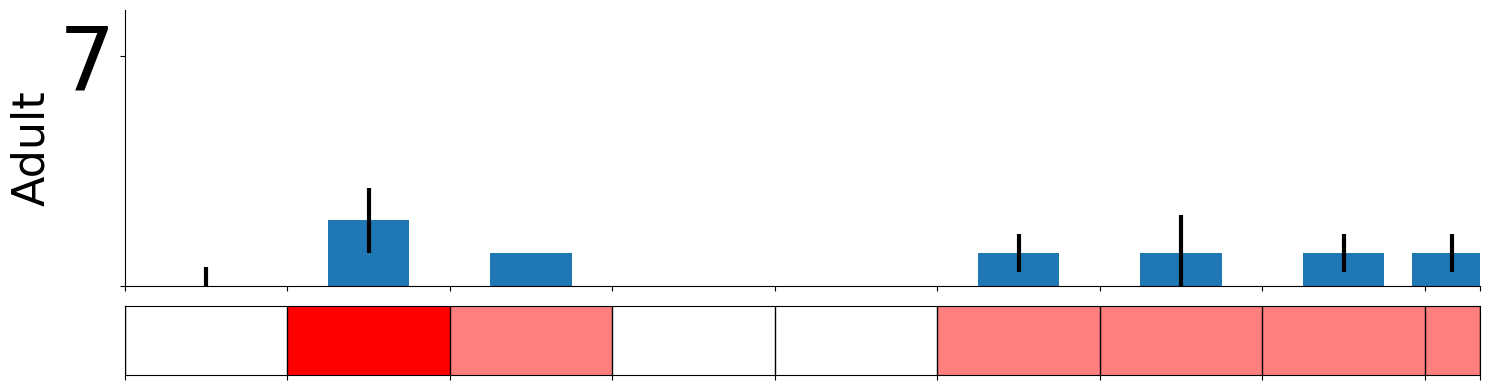

Index: 7 | Data name: female | Significance: * | Y: 3 | O: 1 | P_value: 0.0171


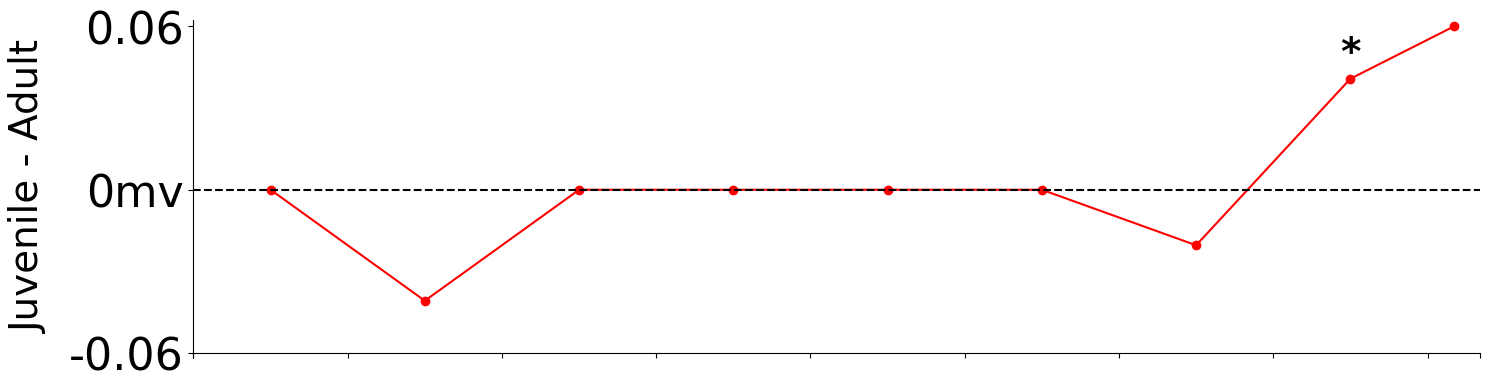

In [13]:
BuildGraph(data_f[data_f['Uniprot_ID'] == 'SERPH_RAT'], g='Average Young', age='fuzzy', s='female', t='Juvenile',  scale=7, save=True)
BuildGraph(data_f[data_f['Uniprot_ID'] == 'SERPH_RAT'], g='Average Old', age='jumbo', s='female', t='Adult',  scale=7, save=True)

buildDiffGraph(data_f[data_f['Uniprot_ID'] == 'SERPH_RAT'], t='female', s='female', addRegion=[], save=True)